In [ ]:
# UPLOAD KAGGLE API FILE

from google.colab import files
files.upload()

# KAGGLE SETUP

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# DOWNLOAD WESAD DATASET

!kaggle datasets download -d orvile/wesad-wearable-stress-affect-detection-dataset

# EXTRACT DATASET

!unzip -o wesad-wearable-stress-affect-detection-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/orvile/wesad-wearable-stress-affect-detection-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 2.43G/2.43G [02:06<00:00, 20.6MB/s]

Archive:  wesad-wearable-stress-affect-detection-dataset.zip
  inflating: WESAD/S10/S10.pkl       
  inflating: WESAD/S10/S10_E4_Data/ACC.csv  
  inflating: WESAD/S10/S10_E4_Data/BVP.csv  
  inflating: WESAD/S10/S10_E4_Data/EDA.csv  
  inflating: WESAD/S10/S10_E4_Data/HR.csv  
  inflating: WESAD/S10/S10_E4_Data/IBI.csv  
  inflating: WESAD/S10/S10_E4_Data/TEMP.csv  
  inflating: WESAD/S10/S10_E4_Data/info.txt  
  inflating: WESAD/S10/S10_E4_Data/tags.csv  
  inflating: WESAD/S10/S10_quest.csv  
  inflating: WESAD/S10/S10_readme.txt  
  inflating: WESAD/S10/S10_respiban.txt  
  inflating: WESAD/S11/S11.pkl       
  inflating: WESAD/S11/S11_E4_Data/ACC.csv  
  inflating: WESAD/S11/S11_E4_Data/BVP.csv  
  inflating: WESAD/S11/S11_E4_Data/EDA.csv  
  inflating: WES

In [ ]:
import os

# CHECK DATASET FOLDERS

print(os.listdir())

print(os.listdir('/content/WESAD'))

['.config', 'WESAD', 'kaggle.json', 'wesad-wearable-stress-affect-detection-dataset.zip', 'sample_data']
['S17', 'S11', 'S15', 'S4', 'S2', 'S7', 'S10', 'S13', 'S6', 'S16', 'S5', 'S14', 'wesad_readme.pdf', 'S9', 'S3', 'S8']


In [54]:
import pickle

subject_path = '/content/WESAD/S2/S2.pkl'

with open(subject_path, 'rb') as file:
    data = pickle.load(file, encoding='latin1')

print(data.keys())

print(data['signal'].keys())

dict_keys(['signal', 'label', 'subject'])
dict_keys(['chest', 'wrist'])


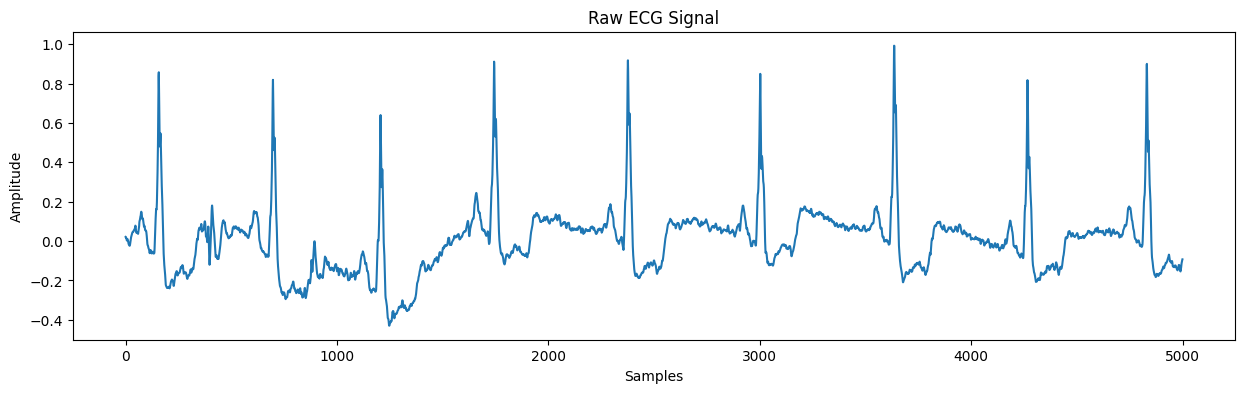

ECG Shape: (4255300,)


In [ ]:
# Extract ECG

ecg = data['signal']['chest']['ECG']
ecg = ecg.flatten()

# Visualize Raw ECG

import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.plot(ecg[:5000])

plt.title("Raw ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()
print("ECG Shape:", ecg.shape)

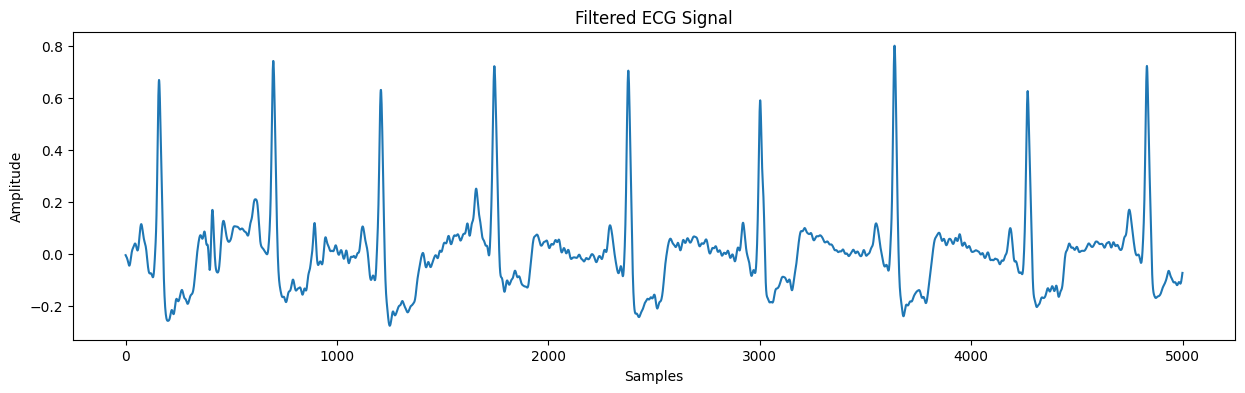

Filtered ECG Shape: (4255300,)


In [ ]:
from scipy.signal import butter, filtfilt

fs = 700

lowcut = 0.5
highcut = 40

b, a = butter(
    4,
    [lowcut/(fs/2), highcut/(fs/2)],
    btype='band'
)

filtered_ecg = filtfilt(b, a, ecg)
plt.figure(figsize=(15,4))

plt.plot(filtered_ecg[:5000])

plt.title("Filtered ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()
print("Filtered ECG Shape:", filtered_ecg.shape)

In [ ]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 39.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/neurokit2/ecg/ecg_plot.py:68: NeuroKitWarning: 'info' dict not provided. Some information might be missing. Sampling rate will be set to 1000 Hz.
  warn(


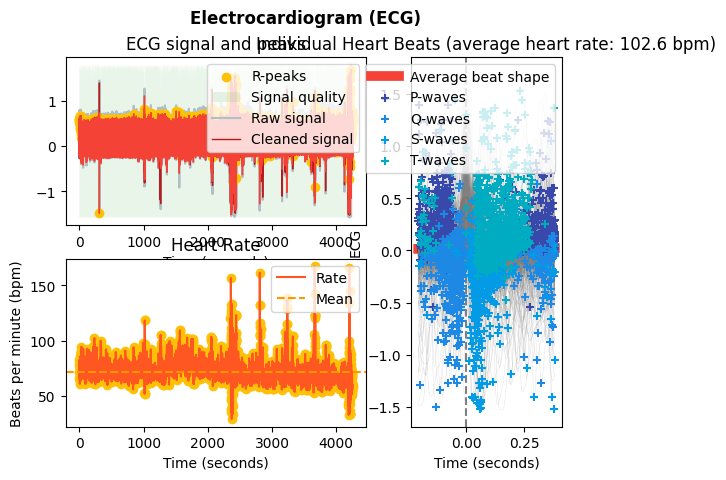

In [ ]:
#ECG Processing
import neurokit2 as nk

signals, info = nk.ecg_process(
    filtered_ecg,
    sampling_rate=700
)

rpeaks = info["ECG_R_Peaks"]
#ECG Plot
nk.ecg_plot(signals)

In [ ]:
#HRV Extraction
hrv_time = nk.hrv_time(
    rpeaks,
    sampling_rate=700,
    show=False
)

hrv_freq = nk.hrv_frequency(
    rpeaks,
    sampling_rate=700,
    show=False
)

In [ ]:
hrv_freq = nk.hrv_frequency(
    rpeaks,
    sampling_rate=700,
    show=False
)

print(hrv_freq)

   HRV_ULF   HRV_VLF    HRV_LF    HRV_HF   HRV_VHF  HRV_TP  HRV_LFHF  \
0   0.0002  0.000899  0.000972  0.000664  0.000165  0.0029  1.463468   

    HRV_LFn   HRV_HFn  HRV_LnHF  
0  0.335131  0.228998 -7.316924  


In [ ]:
#ECG Feature Cell
import pandas as pd

freq_cols = [
    'HRV_ULF',
    'HRV_VLF',
    'HRV_LF',
    'HRV_HF',
    'HRV_VHF',
    'HRV_TP',
    'HRV_LFHF',
    'HRV_LFn',
    'HRV_HFn',
    'HRV_LnHF'
]

hrv_time_filtered = hrv_time.drop(
    columns=[
        col for col in freq_cols
        if col in hrv_time.columns
    ],
    errors='ignore'
)

ecg_features = pd.concat(
    [hrv_time_filtered, hrv_freq],
    axis=1
)

print(ecg_features)

print("NaN Count:")
print(ecg_features.isna().sum())

ecg_features.to_csv(
    "ecg_features.csv",
    index=False
)

   HRV_MeanNN    HRV_SDNN  HRV_SDANN1  HRV_SDNNI1  HRV_SDANN2  HRV_SDNNI2  \
0  836.299121  105.145221   55.200948   79.493874   53.735311   84.274828   

   HRV_SDANN5  HRV_SDNNI5  HRV_RMSSD   HRV_SDSD  ...  HRV_ULF   HRV_VLF  \
0   46.733615   86.123387  83.658996  83.664745  ...   0.0002  0.000899   

     HRV_LF    HRV_HF   HRV_VHF  HRV_TP  HRV_LFHF   HRV_LFn   HRV_HFn  \
0  0.000972  0.000664  0.000165  0.0029  1.463468  0.335131  0.228998   

   HRV_LnHF  
0 -7.316924  

[1 rows x 35 columns]
NaN Count:
HRV_MeanNN      0
HRV_SDNN        0
HRV_SDANN1      0
HRV_SDNNI1      0
HRV_SDANN2      0
HRV_SDNNI2      0
HRV_SDANN5      0
HRV_SDNNI5      0
HRV_RMSSD       0
HRV_SDSD        0
HRV_CVNN        0
HRV_CVSD        0
HRV_MedianNN    0
HRV_MadNN       0
HRV_MCVNN       0
HRV_IQRNN       0
HRV_SDRMSSD     0
HRV_Prc20NN     0
HRV_Prc80NN     0
HRV_pNN50       0
HRV_pNN20       0
HRV_MinNN       0
HRV_MaxNN       0
HRV_HTI         0
HRV_TINN        0
HRV_ULF         0
HRV_VLF         0

In [ ]:
#save ECG Features
ecg_features.to_csv(
    "ecg_features.csv",
    index=False
)

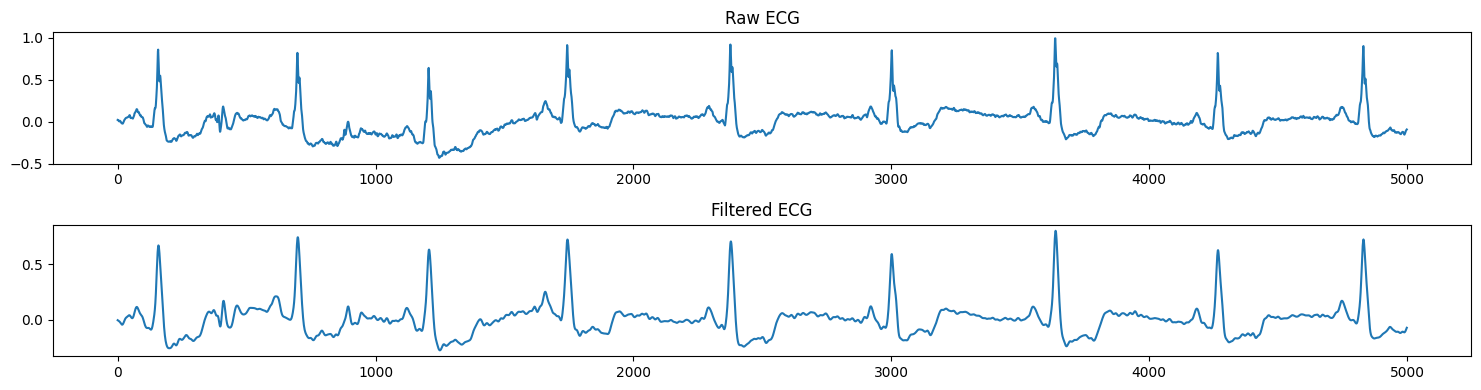

In [ ]:
plt.figure(figsize=(15,4))

plt.subplot(2,1,1)
plt.plot(ecg[:5000])
plt.title("Raw ECG")

plt.subplot(2,1,2)
plt.plot(filtered_ecg[:5000])
plt.title("Filtered ECG")

plt.tight_layout()
plt.show()

EDA Shape: (24316,)
EDA Sampling Rate = 4 Hz


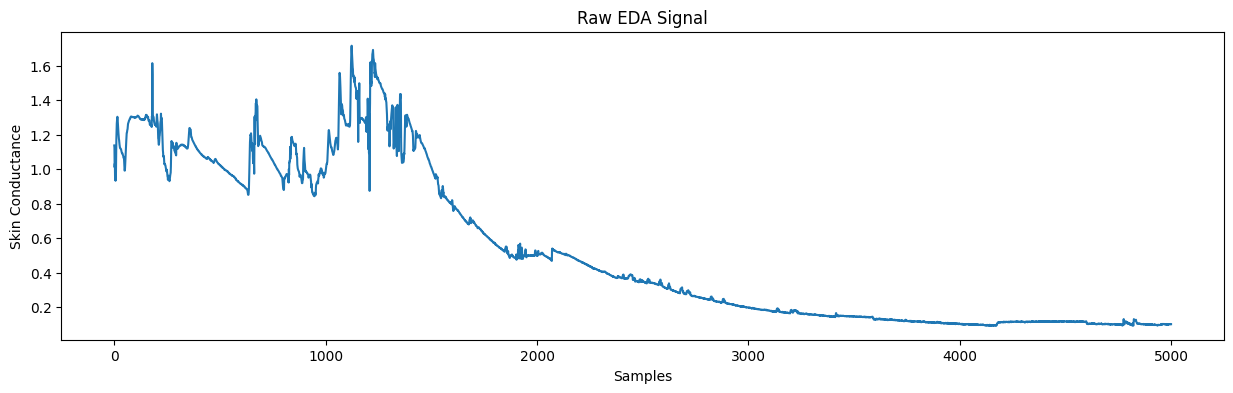

In [ ]:
# EXTRACT EDA

eda = data['signal']['wrist']['EDA']

eda = eda.flatten()

print("EDA Shape:", eda.shape)
print("EDA Sampling Rate = 4 Hz")

# VISUALIZE RAW EDA

plt.figure(figsize=(15,4))

plt.plot(eda[:5000])

plt.title("Raw EDA Signal")

plt.xlabel("Samples")

plt.ylabel("Skin Conductance")

plt.show()

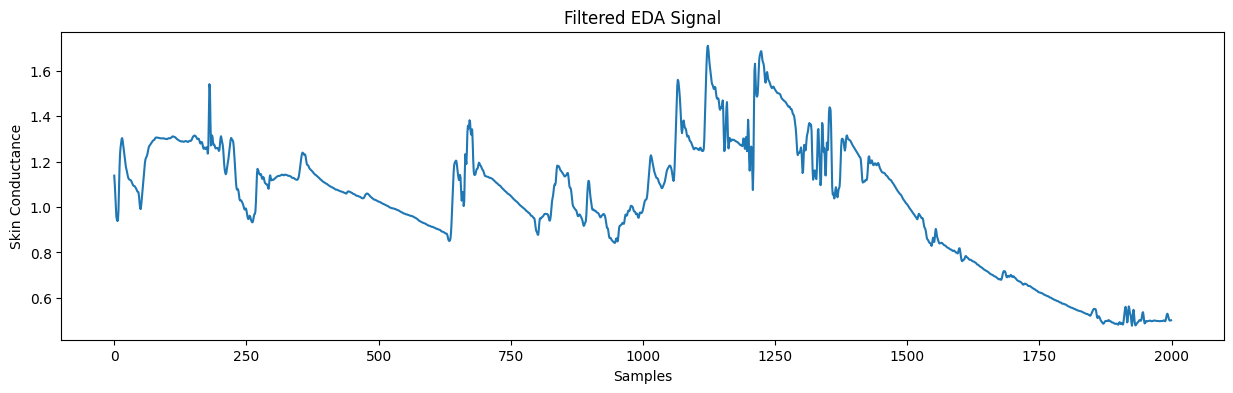

Filtered EDA Shape: (24316,)


In [ ]:
from scipy.signal import butter, filtfilt

fs_eda = 4

b, a = butter(
    4,
    1/(fs_eda/2),
    btype='low'
)

filtered_eda = filtfilt(b, a, eda)

plt.figure(figsize=(15,4))

plt.plot(filtered_eda[:2000])

plt.title("Filtered EDA Signal")
plt.xlabel("Samples")
plt.ylabel("Skin Conductance")

plt.show()
print("Filtered EDA Shape:", filtered_eda.shape)

/usr/local/lib/python3.12/dist-packages/neurokit2/eda/eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/eda/eda_plot.py:49: NeuroKitWarning: 'info' dict not provided. Some information might be missing. Sampling rate will be set to 1000 Hz.
  warn(


Index(['EDA_Raw', 'EDA_Clean', 'EDA_Tonic', 'EDA_Phasic', 'SCR_Onsets',
       'SCR_Peaks', 'SCR_Height', 'SCR_Amplitude', 'SCR_RiseTime',
       'SCR_Recovery', 'SCR_RecoveryTime'],
      dtype='object')


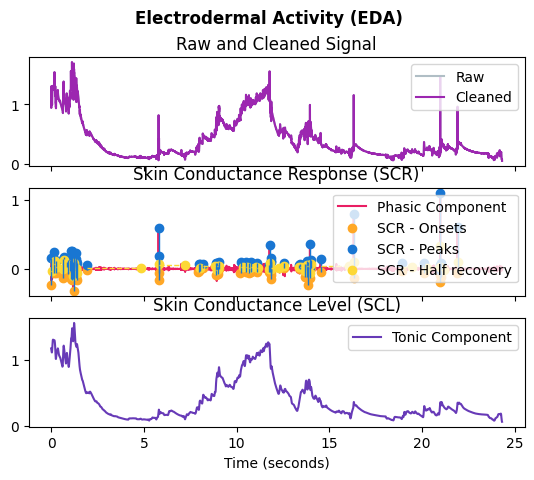

In [ ]:
#EDA Signal Processing (SCR/SCL Analysis)
import neurokit2 as nk

eda_signals, eda_info = nk.eda_process(
    filtered_eda,
    sampling_rate=4
)
nk.eda_plot(eda_signals)
print(eda_signals.columns)

In [ ]:
#eda feature extracton
eda_features = nk.eda_analyze(
    eda_signals,
    sampling_rate=4
)

print(eda_features)
print("\nEDA NaN Count:")

print(
    eda_features.isna().sum()
)

   SCR_Peaks_N  SCR_Peaks_Amplitude_Mean  EDA_Tonic_SD  EDA_Sympathetic  \
0         61.0                  0.225263      0.327795         0.000496   

   EDA_SympatheticN  EDA_Autocorrelation  
0          0.017815             0.987392  

EDA NaN Count:
SCR_Peaks_N                 0
SCR_Peaks_Amplitude_Mean    0
EDA_Tonic_SD                0
EDA_Sympathetic             0
EDA_SympatheticN            0
EDA_Autocorrelation         0
dtype: int64


In [ ]:
eda_features.to_csv(
    "eda_features.csv",
    index=False
)

In [ ]:
#Feature Fusion
import pandas as pd

ecg_features = pd.read_csv(
    "ecg_features.csv"
)

eda_features = pd.read_csv(
    "eda_features.csv"
)

fused_features = pd.concat(
    [ecg_features, eda_features],
    axis=1
)

print(fused_features.shape)
print("\nFused Feature NaNs:")

print(
    fused_features.isna().sum().sum()
)

print(fused_features.head())

(1, 41)

Fused Feature NaNs:
0
   HRV_MeanNN    HRV_SDNN  HRV_SDANN1  HRV_SDNNI1  HRV_SDANN2  HRV_SDNNI2  \
0  836.299121  105.145221   55.200948   79.493874   53.735311   84.274828   

   HRV_SDANN5  HRV_SDNNI5  HRV_RMSSD   HRV_SDSD  ...  HRV_LFHF   HRV_LFn  \
0   46.733615   86.123387  83.658996  83.664745  ...  1.463468  0.335131   

    HRV_HFn  HRV_LnHF  SCR_Peaks_N  SCR_Peaks_Amplitude_Mean  EDA_Tonic_SD  \
0  0.228998 -7.316924         61.0                  0.225263      0.327795   

   EDA_Sympathetic  EDA_SympatheticN  EDA_Autocorrelation  
0         0.000496          0.017815             0.987392  

[1 rows x 41 columns]


In [ ]:
fused_features.to_csv(
    "fused_features.csv",
    index=False
)

In [ ]:
# LABEL INSPECTION

import numpy as np

# LOAD ORIGINAL WESAD LABELS

labels = data['label']

print("Label Shape:", labels.shape)

# SHOW UNIQUE LABELS

print("Unique Labels:")

print(np.unique(labels))

# COUNT EACH LABEL

unique_labels, counts = np.unique(
    labels,
    return_counts=True
)

for label, count in zip(
    unique_labels,
    counts
):
    print(
        f"Label {label}: {count}"
    )

Label Shape: (4255300,)
Unique Labels:
[0 1 2 3 4 6 7]
Label 0: 2142701
Label 1: 800800
Label 2: 430500
Label 3: 253400
Label 4: 537599
Label 6: 45500
Label 7: 44800


In [ ]:
# KEEP ONLY VALID EMOTIONAL STATES

valid_mask = np.isin(
    labels,
    [1, 2, 3, 4]
)

clean_labels = labels[valid_mask]

print("Clean Labels Shape:")
print(clean_labels.shape)

print("Unique Labels:")
print(np.unique(clean_labels))

# STRESS = 1
# BASELINE + AMUSEMENT + MEDITATION = 0

binary_labels = np.where(
    clean_labels == 2,
    1,
    0
)

print("\nBinary Labels:")

print(
    np.unique(
        binary_labels,
        return_counts=True
    )
)

Clean Labels Shape:
(2022299,)
Unique Labels:
[1 2 3 4]

Binary Labels:
(array([0, 1]), array([1591799,  430500]))


In [ ]:

# ECG WINDOW GENERATION

window_size = 30 * 700      # 30 seconds

step_size = 15 * 700        # 15 seconds overlap

ecg_windows = []

for start in range(

    0,

    len(filtered_ecg) - window_size,

    step_size

):

    segment = filtered_ecg[
        start : start + window_size
    ]

    ecg_windows.append(segment)

ecg_windows = np.array(ecg_windows)

print("ECG Windows Shape:")

print(ecg_windows.shape)

print("Total ECG Windows:")

print(len(ecg_windows))

ECG Windows Shape:
(404, 21000)
Total ECG Windows:
404


In [ ]:
# EDA WINDOW GENERATION

eda_window_size = 30 * 4      # 30 seconds

eda_step_size = 15 * 4        # 15 seconds overlap

eda_windows = []

for start in range(

    0,

    len(filtered_eda) - eda_window_size,

    eda_step_size

):

    segment = filtered_eda[
        start : start + eda_window_size
    ]

    eda_windows.append(segment)

eda_windows = np.array(eda_windows)

print("EDA Windows Shape:")

print(eda_windows.shape)

print("Total EDA Windows:")

print(len(eda_windows))

EDA Windows Shape:
(404, 120)
Total EDA Windows:
404


In [ ]:
print(ecg_windows.shape)
print(eda_windows.shape)

(404, 21000)
(404, 120)


In [ ]:

# WINDOW-WISE LABEL GENERATION

window_size = 30 * 700      # 30 seconds

step_size = 15 * 700        # 15 second overlap

window_labels = []

for start in range(

    0,

    len(labels) - window_size,

    step_size

):

    label_window = labels[
        start : start + window_size
    ]

    # Keep valid emotion labels only
    valid = label_window[
        np.isin(label_window, [1, 2, 3, 4])
    ]

    if len(valid) == 0:

        majority_label = 0

    else:

        majority_label = np.bincount(
            valid.astype(int)
        ).argmax()

    # Stress = 1
    # Baseline/Amusement/Meditation = 0

    binary_label = (
        1 if majority_label == 2 else 0
    )

    window_labels.append(
        binary_label
    )

window_labels = np.array(
    window_labels
)

print("Window Labels Shape:")
print(window_labels.shape)

print("\nClass Distribution:")
print(
    np.unique(
        window_labels,
        return_counts=True
    )
)

Window Labels Shape:
(404,)

Class Distribution:
(array([0, 1]), array([361,  43]))


In [ ]:
print("ECG Signal Length:", len(filtered_ecg))

print("Label Length:", len(labels))

print("ECG Duration (sec):", len(filtered_ecg)/700)

print("Label Duration (sec):", len(labels)/700)

ECG Signal Length: 4255300
Label Length: 4255300
ECG Duration (sec): 6079.0
Label Duration (sec): 6079.0


In [ ]:

# ECG WINDOW FEATURE EXTRACTION

import neurokit2 as nk
import pandas as pd
import numpy as np

ecg_feature_list = []

for segment in ecg_windows:

    try:

        signals, info = nk.ecg_process(
            segment,
            sampling_rate=700
        )

        hrv_time = nk.hrv_time(
            info,
            sampling_rate=700,
            show=False
        )

        hrv_freq = nk.hrv_frequency(
            info,
            sampling_rate=700,
            show=False
        )

        # Remove duplicate frequency features
        freq_cols = [
            'HRV_ULF','HRV_VLF','HRV_LF',
            'HRV_HF','HRV_VHF','HRV_TP',
            'HRV_LFHF','HRV_LFn',
            'HRV_HFn','HRV_LnHF'
        ]

        hrv_time = hrv_time.drop(
            columns=[
                col for col in freq_cols
                if col in hrv_time.columns
            ],
            errors='ignore'
        )

        features = pd.concat(
            [hrv_time, hrv_freq],
            axis=1
        )

        ecg_feature_list.append(features)

    except Exception as e:

        print("Skipped ECG Window")

        continue

# CREATE DATAFRAME

ecg

array([ 0.02142334,  0.02032471,  0.01652527, ..., -0.00544739,
        0.00013733,  0.0040741 ])

In [ ]:

# CONVERT ECG FEATURES TO DATAFRAME
ecg_features_df = pd.concat(
    ecg_feature_list,
    ignore_index=True
)

print("ECG Feature Shape:")

print(ecg_features_df.shape)

print("\nNaN Count:")

print(
    ecg_features_df.isna().sum().sum()
)

ecg_features_df.head()

ECG Feature Shape:
(404, 35)

NaN Count:
4444


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_ULF,HRV_VLF,HRV_LF,HRV_HF,HRV_VHF,HRV_TP,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF
0,837.268908,78.296147,NaN,NaN,NaN,NaN,NaN,NaN,54.333540,54.947901,...,NaN,NaN,NaN,0.012266,0.000863,0.013130,NaN,NaN,0.934251,-4.400893
1,792.277992,84.704006,NaN,NaN,NaN,NaN,NaN,NaN,35.459408,35.901460,...,NaN,NaN,NaN,0.007833,0.000265,0.008098,NaN,NaN,0.967257,-4.849414
2,743.333333,64.075122,NaN,NaN,NaN,NaN,NaN,NaN,28.902220,29.175389,...,NaN,NaN,NaN,0.005377,0.001337,0.006714,NaN,NaN,0.800917,-5.225613
3,758.721805,52.421548,NaN,NaN,NaN,NaN,NaN,NaN,39.789851,40.191367,...,NaN,NaN,NaN,0.011392,0.004694,0.016086,NaN,NaN,0.708192,-4.474819
4,767.490347,43.078009,NaN,NaN,NaN,NaN,NaN,NaN,36.946980,37.346034,...,NaN,NaN,NaN,0.050265,0.005002,0.055267,NaN,NaN,0.909497,-2.990438


In [ ]:

# SAVE ECG WINDOW FEATURES

ecg_features_df.to_csv(
    "ecg_window_features.csv",
    index=False
)

In [ ]:
print(ecg_features_df.shape)

(404, 35)


In [ ]:

# EDA WINDOW FEATURE EXTRACTION

import neurokit2 as nk
import pandas as pd

eda_feature_list = []

for segment in eda_windows:

    try:

        eda_signals, eda_info = nk.eda_process(
            segment,
            sampling_rate=4
        )

        features = nk.eda_analyze(
            eda_signals,
            sampling_rate=4
        )

        eda_feature_list.append(
            features
        )

    except Exception as e:

        print("Skipped EDA Window")

        continue

/usr/local/lib/python3.12/dist-packages/neurokit2/eda/eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/eda/eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/eda/eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/eda/eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/eda/eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/eda/eda_clean.py:102: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(
/usr/local/lib/python3.12/di

In [ ]:

# CONVERT TO DATAFRAME

eda_features_df = pd.concat(
    eda_feature_list,
    ignore_index=True
)

print("EDA Feature Shape:")

print(eda_features_df.shape)

print("\nNaN Count:")

print(
    eda_features_df.isna().sum().sum()
)

eda_features_df.head()

EDA Feature Shape:
(404, 6)

NaN Count:
1212


,SCR_Peaks_N,SCR_Peaks_Amplitude_Mean,EDA_Tonic_SD,EDA_Sympathetic,EDA_SympatheticN,EDA_Autocorrelation
0,2.0,0.197804,0.076128,NaN,NaN,NaN
1,3.0,0.014578,0.020042,NaN,NaN,NaN
2,4.0,0.107736,0.049036,NaN,NaN,NaN
3,4.0,0.107536,0.138244,NaN,NaN,NaN
4,4.0,0.076973,0.053634,NaN,NaN,NaN


In [ ]:
eda_features_df.to_csv(
    "eda_window_features.csv",
    index=False
)

In [ ]:
print(eda_features_df.shape)

(404, 6)


In [ ]:

# MULTIMODAL FEATURE FUSION
import pandas as pd

fused_features = pd.concat(

    [
        ecg_features_df,
        eda_features_df
    ],

    axis=1

)

print("Fused Shape:")

print(
    fused_features.shape
)

print("\nTotal NaNs:")

print(
    fused_features.isna().sum().sum()
)

Fused Shape:
(404, 41)

Total NaNs:
5656


In [ ]:
# CHECK WHICH FEATURES HAVE NaNs

nan_counts = fused_features.isna().sum()

for col in fused_features.columns:

    if nan_counts[col] > 0:

        print(
            col,
            ":",
            nan_counts[col]
        )

HRV_SDANN1 : 404
HRV_SDNNI1 : 404
HRV_SDANN2 : 404
HRV_SDNNI2 : 404
HRV_SDANN5 : 404
HRV_SDNNI5 : 404
HRV_ULF : 404
HRV_VLF : 404
HRV_LF : 404
HRV_LFHF : 404
HRV_LFn : 404
EDA_Sympathetic : 404
EDA_SympatheticN : 404
EDA_Autocorrelation : 404


In [ ]:

# REMOVE FULLY NaN FEATURES

fused_features_clean = fused_features.dropna(
    axis=1,
    how='all'
)

print("Original Shape:")
print(fused_features.shape)

print("\nClean Shape:")
print(fused_features_clean.shape)

print("\nRemaining NaNs:")
print(
    fused_features_clean.isna().sum().sum()
)

Original Shape:
(404, 41)

Clean Shape:
(404, 27)

Remaining NaNs:
0


In [ ]:
fused_features_clean = fused_features.dropna(
    axis=1,
    how='all'
)

print(fused_features.shape)
print(fused_features_clean.shape)

(404, 41)
(404, 27)


In [ ]:

# FINAL DATASET

X = fused_features_clean.values

y = window_labels

print("X Shape:", X.shape)

print("y Shape:", y.shape)

print(
    np.unique(
        y,
        return_counts=True
    )
)

X Shape: (404, 27)
y Shape: (404,)
(array([0, 1]), array([361,  43]))


In [ ]:
#random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
# ACCURACY

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)
print("Accuracy:", accuracy)
print(classification_report(
    y_test,
    y_pred
))


Accuracy: 0.9259259259259259
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        72
           1       0.71      0.56      0.62         9

    accuracy                           0.93        81
   macro avg       0.83      0.76      0.79        81
weighted avg       0.92      0.93      0.92        81



In [ ]:
# REMOVE FULLY NaN FEATURES

fused_features_clean = fused_features.dropna(
    axis=1,
    how='all'
)

X = fused_features_clean.values

y = window_labels


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:

#XGBOOST
from xgboost import XGBClassifier

# CREATE MODEL

model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# TRAIN

model.fit(
    X_train,
    y_train
)

# PREDICT

y_pred = model.predict(
    X_test
)

# ACCURACY

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

# CLASSIFICATION REPORT

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.9135802469135802
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.75      0.33      0.46         9

    accuracy                           0.91        81
   macro avg       0.84      0.66      0.71        81
weighted avg       0.90      0.91      0.90        81



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[71  1]
 [ 6  3]]


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({

    'Feature': fused_features_clean.columns,

    'Importance': model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(
    feature_importance.head(10)
)

                     Feature  Importance
12               HRV_Prc80NN    0.229498
14                 HRV_pNN20    0.212879
2                  HRV_RMSSD    0.054767
15                 HRV_MinNN    0.046159
16                 HRV_MaxNN    0.044225
24               SCR_Peaks_N    0.037775
25  SCR_Peaks_Amplitude_Mean    0.035191
0                 HRV_MeanNN    0.033073
10               HRV_SDRMSSD    0.029862
22                   HRV_HFn    0.029718


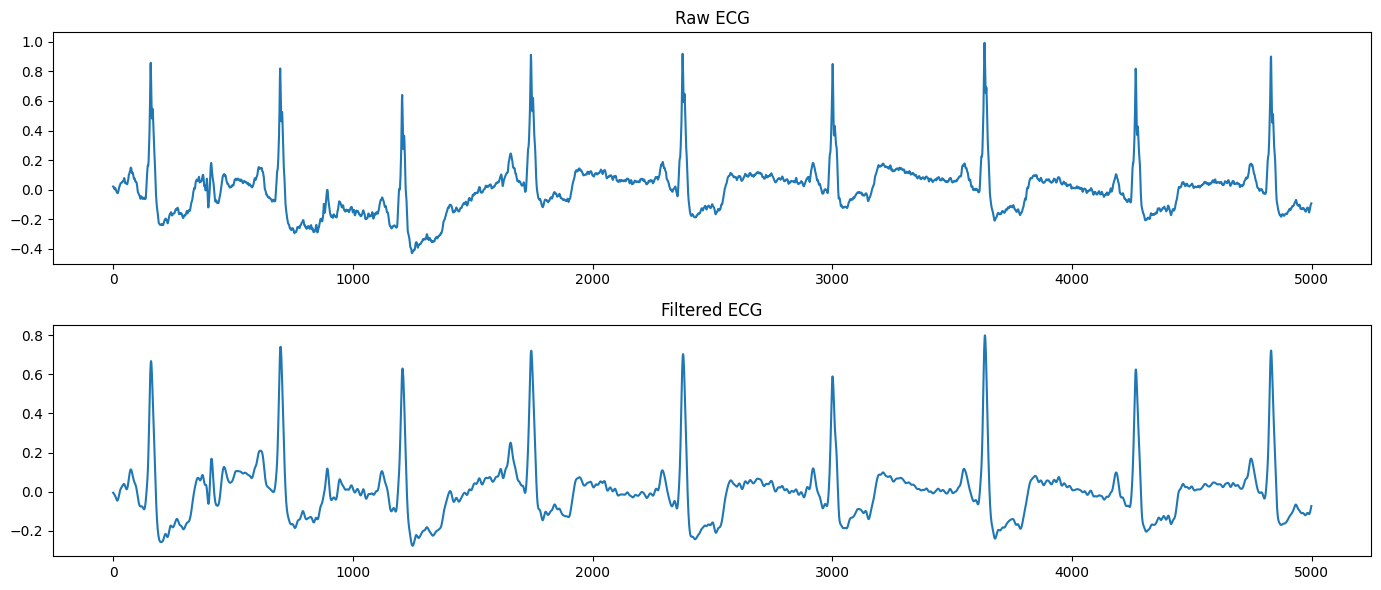

In [ ]:
#ECG RAW vs FILTERED COMPARISON
plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.plot(ecg[:5000])
plt.title("Raw ECG")

plt.subplot(2,1,2)
plt.plot(filtered_ecg[:5000])
plt.title("Filtered ECG")

plt.tight_layout()

plt.show()

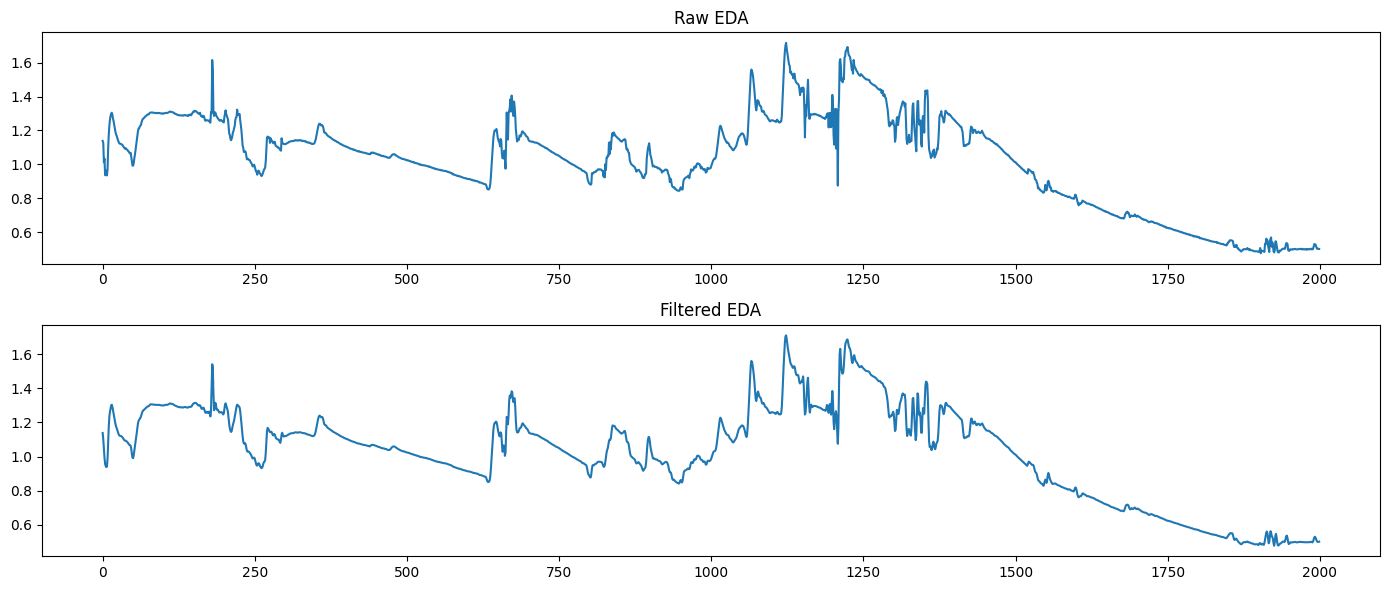

In [ ]:
#EDA RAW vs FILTERED COMPARISON
plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.plot(eda[:2000])
plt.title("Raw EDA")

plt.subplot(2,1,2)
plt.plot(filtered_eda[:2000])
plt.title("Filtered EDA")

plt.tight_layout()

plt.show()

In [ ]:

# ADVANCED ECG PROCESSING
# ADAPTIVE CEEMDAN


!pip install PyEMD
!pip install EMD-signal

from PyEMD import CEEMDAN
import matplotlib.pyplot as plt
import numpy as np


# APPLY CEEMDAN


ceemdan = CEEMDAN()

ecg_sample = filtered_ecg[:10000]

imfs = ceemdan(ecg_sample)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.16
    Uninstalling multiprocess-0.70.16:
      Successfully uninstalled multiprocess-0.70.16
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour

IMF Shape: (12, 10000)
Number of IMFs: 12


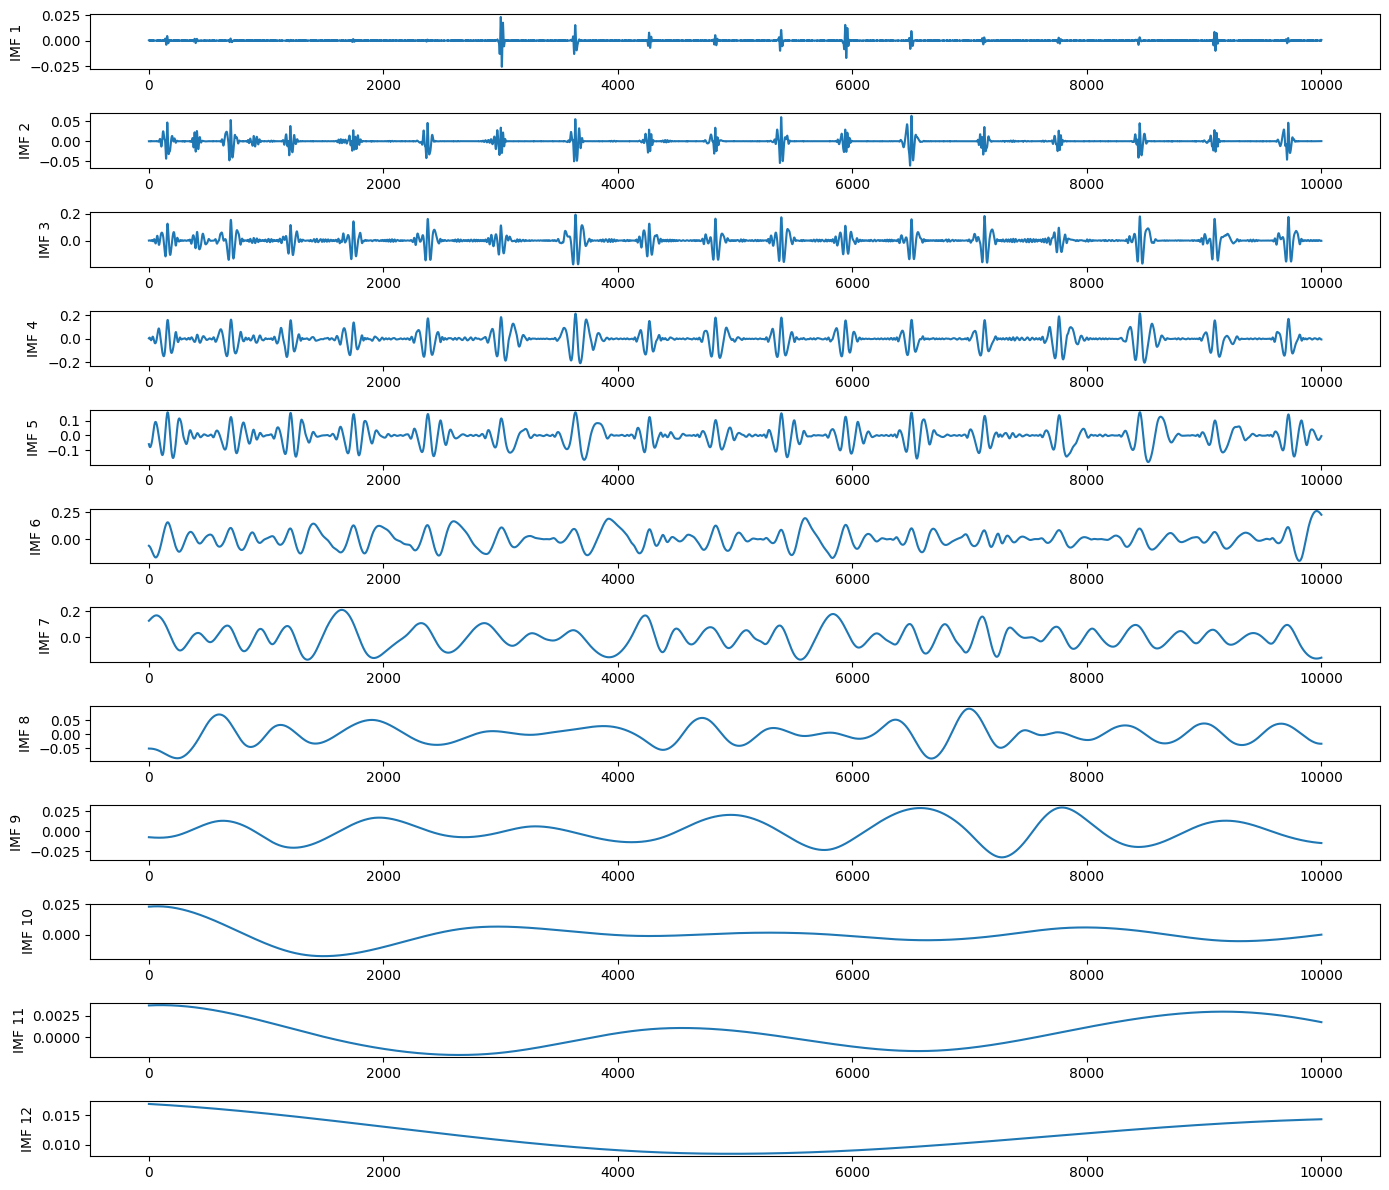


IMF Energies:

[np.float64(0.02095391104185199), np.float64(0.7198375820176385), np.float64(15.21963023522445), np.float64(32.51590407505762), np.float64(31.900987424597073), np.float64(54.7494411205228), np.float64(62.56381991594508), np.float64(10.91516406537638), np.float64(1.9199818632696384), np.float64(0.5610283920488901), np.float64(0.031069907371410445), np.float64(1.4227710752575182)]


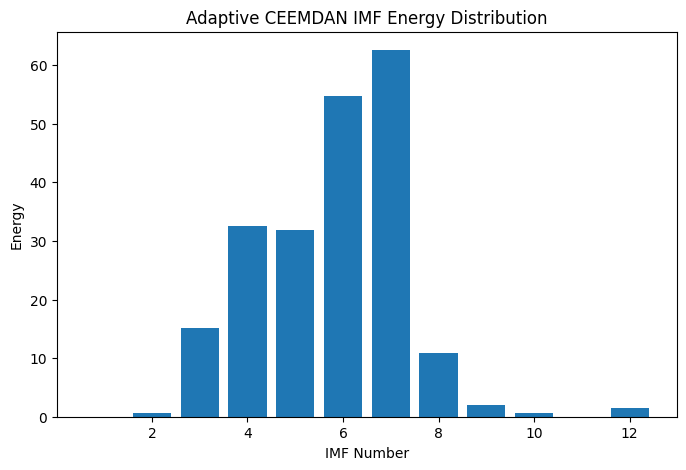


Energy Threshold: 17.711715797310863
Selected IMFs: 4


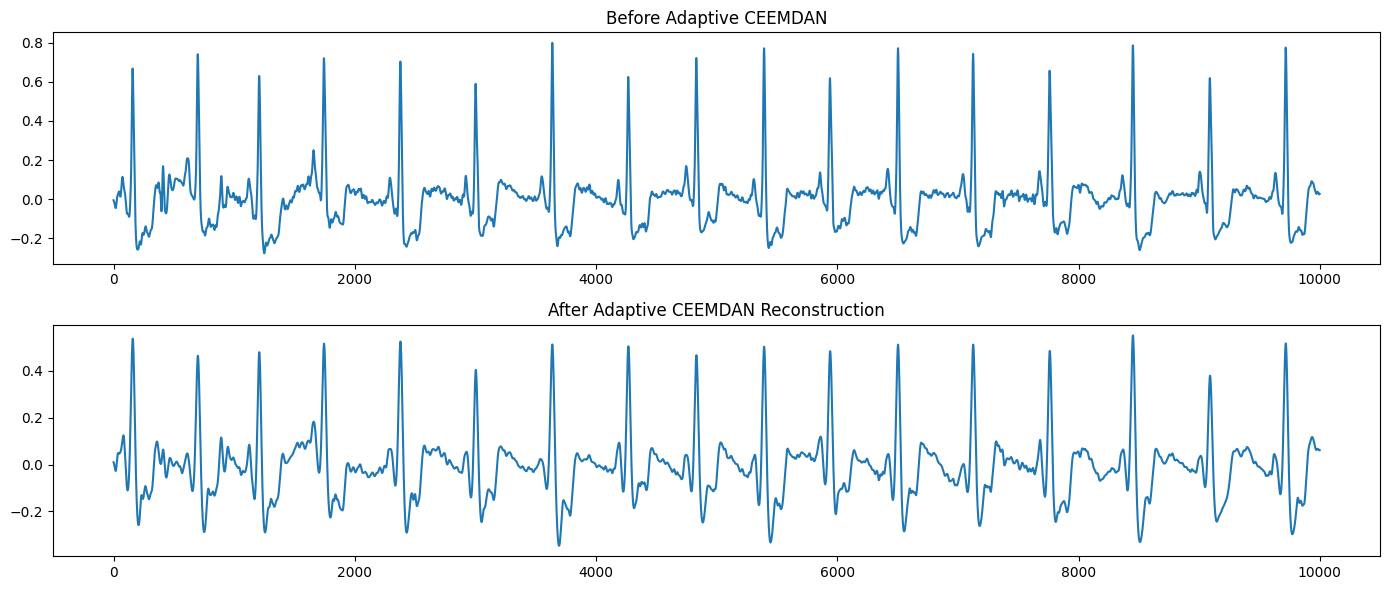


SNR (dB): 7.593286929197648

Reconstructed ECG Saved Successfully


In [ ]:

print("IMF Shape:", imfs.shape)

print("Number of IMFs:", len(imfs))


# IMF VISUALIZATION


plt.figure(figsize=(14,12))

for i in range(len(imfs)):

    plt.subplot(len(imfs),1,i+1)

    plt.plot(imfs[i])

    plt.ylabel(f"IMF {i+1}")

plt.tight_layout()

plt.show()

# ENERGY CALCULATION


imf_energy = []

for imf in imfs:

    energy = np.sum(imf**2)

    imf_energy.append(energy)

print("\nIMF Energies:\n")

print(imf_energy)


# ENERGY DISTRIBUTION


plt.figure(figsize=(8,5))

plt.bar(
    range(1, len(imf_energy)+1),
    imf_energy
)

plt.xlabel("IMF Number")

plt.ylabel("Energy")

plt.title("Adaptive CEEMDAN IMF Energy Distribution")

plt.show()


# ADAPTIVE IMF SELECTION (NOVELTY)


energy_threshold = np.mean(imf_energy)

print("\nEnergy Threshold:", energy_threshold)

selected_imfs = []

for i, energy in enumerate(imf_energy):

    if energy > energy_threshold:

        selected_imfs.append(imfs[i])

print("Selected IMFs:", len(selected_imfs))


# ECG RECONSTRUCTION


reconstructed_ecg = np.sum(
    selected_imfs,
    axis=0
)


# BEFORE VS AFTER

plt.figure(figsize=(14,6))

plt.subplot(2,1,1)

plt.plot(ecg_sample)

plt.title("Before Adaptive CEEMDAN")

plt.subplot(2,1,2)

plt.plot(reconstructed_ecg)

plt.title("After Adaptive CEEMDAN Reconstruction")

plt.tight_layout()

plt.show()

# SNR IMPROVEMENT

signal_power = np.mean(
    reconstructed_ecg**2
)

noise_power = np.mean(
    (ecg_sample - reconstructed_ecg)**2
)

snr = 10 * np.log10(
    signal_power / noise_power
)

print("\nSNR (dB):", snr)


# SAVE RECONSTRUCTED SIGNAL


np.save(
    "reconstructed_ecg.npy",
    reconstructed_ecg
)

print("\nReconstructed ECG Saved Successfully")

In [ ]:
# ADVANCED ECG PROCESSING
# WAVELET DENOISING

!pip install PyWavelets

import pywt
import numpy as np
import matplotlib.pyplot as plt


Number of Coefficient Levels: 5


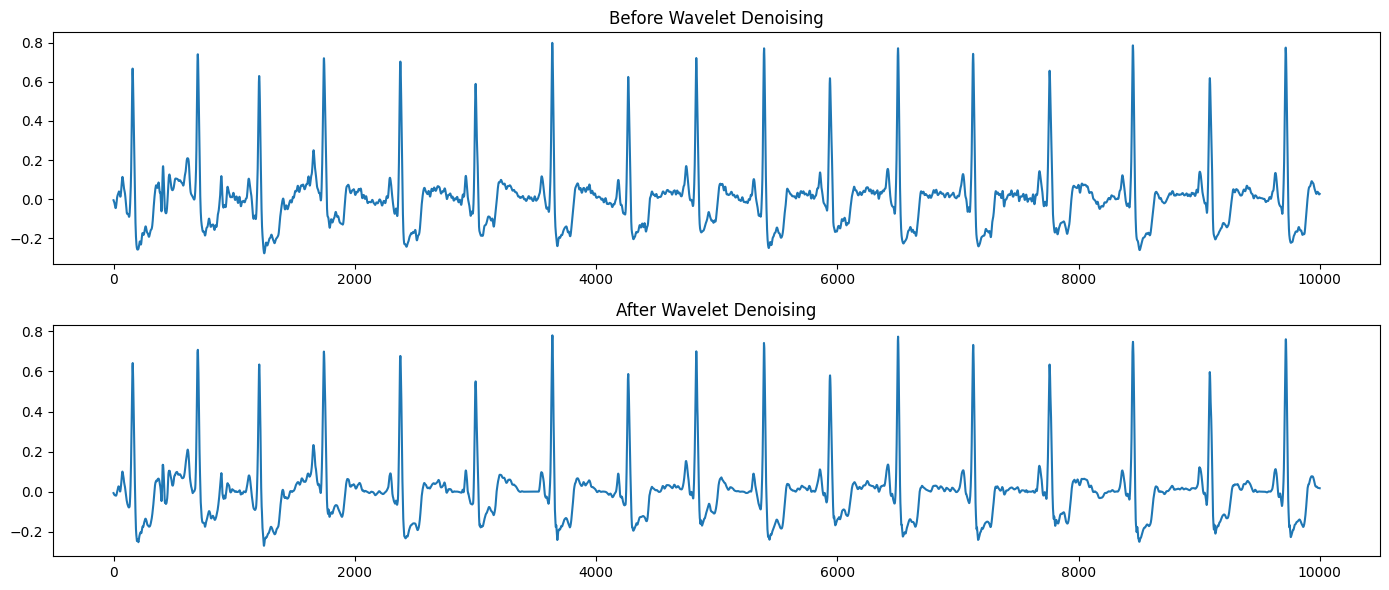


Wavelet SNR (dB): 21.21110790115788

Wavelet ECG Saved Successfully


In [ ]:
# WAVELET DECOMPOSITION


ecg_sample = filtered_ecg[:10000]

coeffs = pywt.wavedec(
    ecg_sample,
    'db4',
    level=4
)

print("Number of Coefficient Levels:", len(coeffs))

# SOFT THRESHOLDING


threshold = 0.04

denoised_coeffs = []

for coeff in coeffs:

    denoised = pywt.threshold(
        coeff,
        threshold,
        mode='soft'
    )

    denoised_coeffs.append(
        denoised
    )

# SIGNAL RECONSTRUCTION


wavelet_ecg = pywt.waverec(
    denoised_coeffs,
    'db4'
)

# Match original length

wavelet_ecg = wavelet_ecg[:len(ecg_sample)]

# VISUALIZATION


plt.figure(figsize=(14,6))

plt.subplot(2,1,1)

plt.plot(ecg_sample)

plt.title("Before Wavelet Denoising")

plt.subplot(2,1,2)

plt.plot(wavelet_ecg)

plt.title("After Wavelet Denoising")

plt.tight_layout()

plt.show()


# SNR CALCULATION


signal_power = np.mean(
    wavelet_ecg**2
)

noise_power = np.mean(
    (ecg_sample - wavelet_ecg)**2
)

snr = 10 * np.log10(
    signal_power / noise_power
)

print("\nWavelet SNR (dB):", snr)



np.save(
    "wavelet_ecg.npy",
    wavelet_ecg
)

print("\nWavelet ECG Saved Successfully")

Adaptive Threshold: 0.0001299391322105361


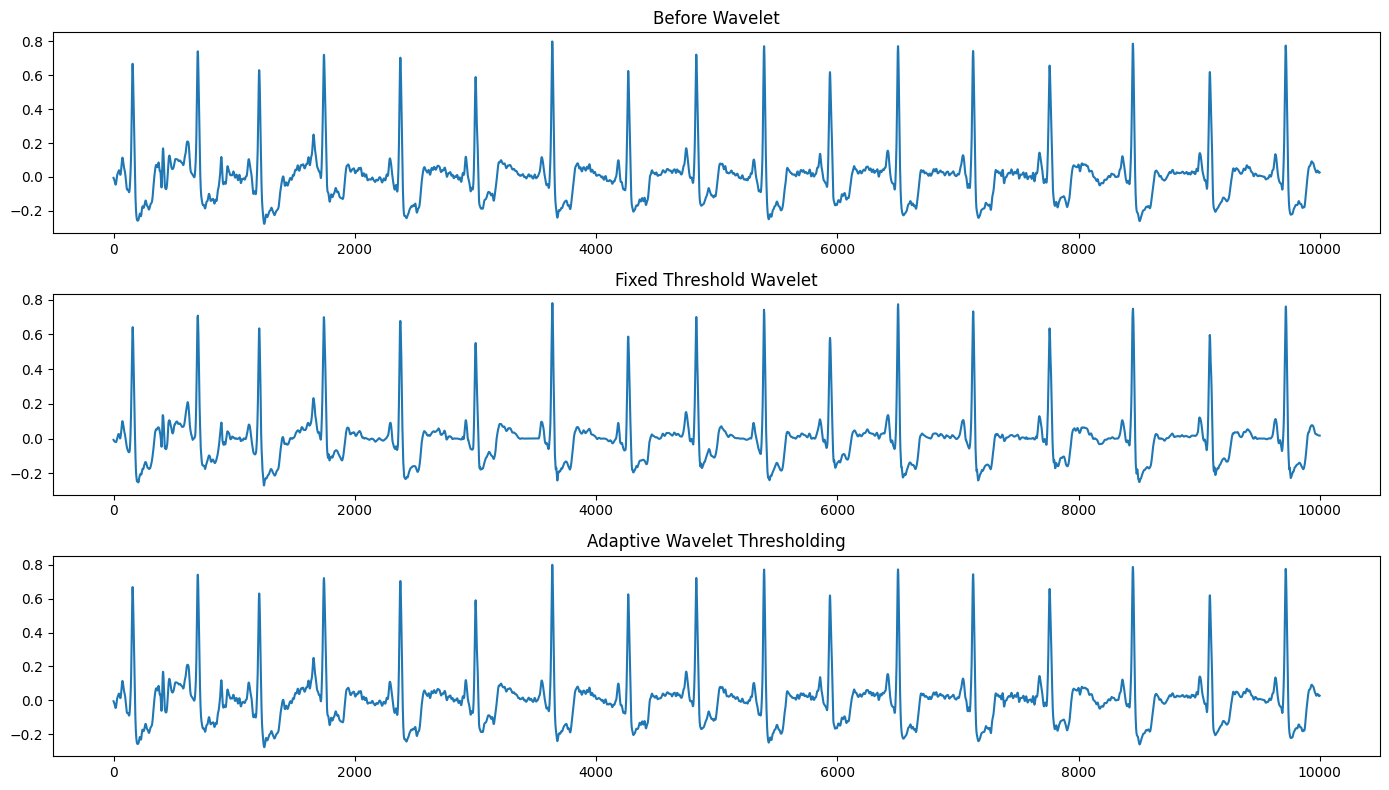


Adaptive Wavelet SNR (dB): 63.95447954488195

Adaptive Wavelet ECG Saved Successfully


In [55]:

# ADAPTIVE WAVELET THRESHOLDING


import numpy as np
import pywt
import matplotlib.pyplot as plt


# ESTIMATE NOISE LEVEL


sigma = np.median(
    np.abs(coeffs[-1])
) / 0.6745

# UNIVERSAL THRESHOLD

threshold = sigma * np.sqrt(
    2 * np.log(len(filtered_ecg))
)

print("Adaptive Threshold:", threshold)


# APPLY ADAPTIVE THRESHOLDING


adaptive_coeffs = []

for coeff in coeffs:

    denoised = pywt.threshold(
        coeff,
        threshold,
        mode='soft'
    )

    adaptive_coeffs.append(
        denoised
    )


# SIGNAL RECONSTRUCTION


adaptive_wavelet_ecg = pywt.waverec(
    adaptive_coeffs,
    'db4'
)

adaptive_wavelet_ecg = adaptive_wavelet_ecg[:len(ecg_sample)]

# VISUALIZATION

plt.figure(figsize=(14,8))

plt.subplot(3,1,1)

plt.plot(ecg_sample)

plt.title("Before Wavelet")

plt.subplot(3,1,2)

plt.plot(wavelet_ecg)

plt.title("Fixed Threshold Wavelet")

plt.subplot(3,1,3)

plt.plot(adaptive_wavelet_ecg)

plt.title("Adaptive Wavelet Thresholding")

plt.tight_layout()

plt.show()


# SNR COMPARISON

signal_power = np.mean(
    adaptive_wavelet_ecg**2
)

noise_power = np.mean(
    (ecg_sample - adaptive_wavelet_ecg)**2
)

adaptive_snr = 10 * np.log10(
    signal_power / noise_power
)

print(
    "\nAdaptive Wavelet SNR (dB):",
    adaptive_snr
)

# SAVE SIGNAL

np.save(
    "adaptive_wavelet_ecg.npy",
    adaptive_wavelet_ecg
)

print(
    "\nAdaptive Wavelet ECG Saved Successfully"
)

Hybrid Adaptive Threshold: 1.0899052078482072e-05


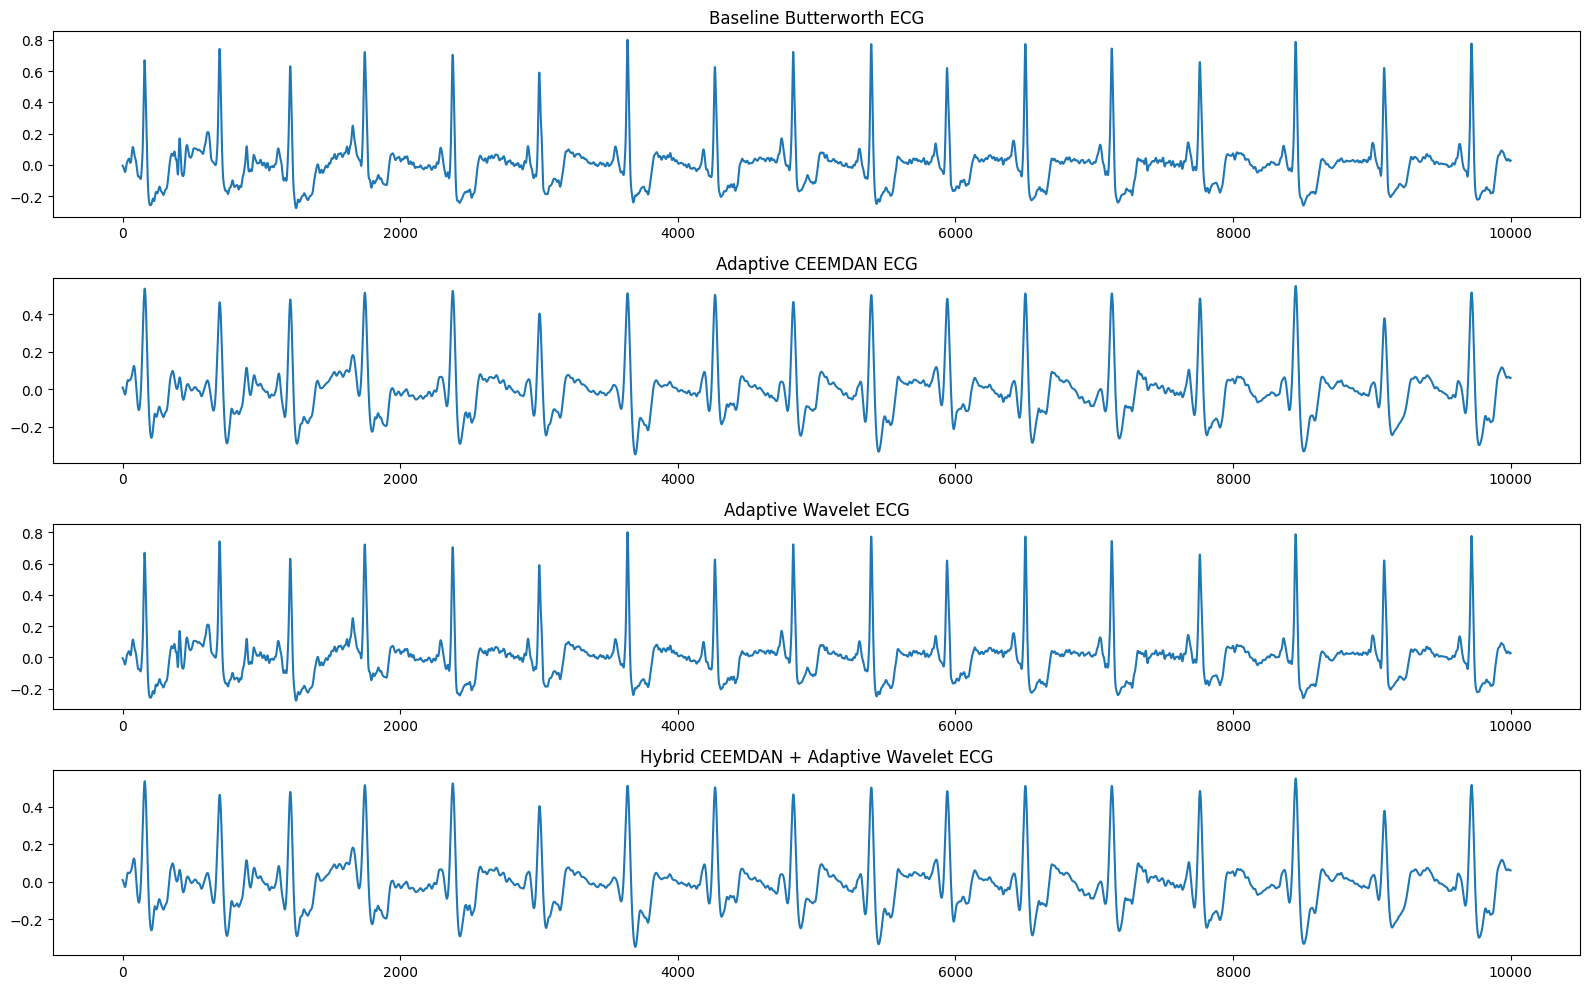


Hybrid SNR (dB): 7.593235790847942

Hybrid ECG Saved Successfully


In [56]:

# HYBRID CEEMDAN + ADAPTIVE WAVELET ECG

import numpy as np
import pywt
import matplotlib.pyplot as plt

# WAVELET DECOMPOSITION ON CEEMDAN ECG

coeffs_hybrid = pywt.wavedec(
    reconstructed_ecg,
    'db4',
    level=4
)

# ADAPTIVE THRESHOLD

sigma_hybrid = np.median(
    np.abs(coeffs_hybrid[-1])
) / 0.6745

threshold_hybrid = sigma_hybrid * np.sqrt(
    2 * np.log(len(reconstructed_ecg))
)

print(
    "Hybrid Adaptive Threshold:",
    threshold_hybrid
)

# ADAPTIVE THRESHOLDING

hybrid_coeffs = []

for coeff in coeffs_hybrid:

    denoised = pywt.threshold(
        coeff,
        threshold_hybrid,
        mode='soft'
    )

    hybrid_coeffs.append(
        denoised
    )

# RECONSTRUCTION
hybrid_ecg = pywt.waverec(
    hybrid_coeffs,
    'db4'
)

hybrid_ecg = hybrid_ecg[
    :len(reconstructed_ecg)
]

# FINAL COMPARISON


plt.figure(figsize=(16,10))

plt.subplot(4,1,1)

plt.plot(filtered_ecg[:10000])

plt.title("Baseline Butterworth ECG")

plt.subplot(4,1,2)

plt.plot(reconstructed_ecg)

plt.title("Adaptive CEEMDAN ECG")

plt.subplot(4,1,3)

plt.plot(adaptive_wavelet_ecg)

plt.title("Adaptive Wavelet ECG")

plt.subplot(4,1,4)

plt.plot(hybrid_ecg)

plt.title("Hybrid CEEMDAN + Adaptive Wavelet ECG")

plt.tight_layout()

plt.show()

# SNR CALCULATION

signal_power = np.mean(
    hybrid_ecg**2
)

noise_power = np.mean(
    (
        filtered_ecg[:10000]
        -
        hybrid_ecg
    )**2
)

hybrid_snr = 10 * np.log10(
    signal_power / noise_power
)

print(
    "\nHybrid SNR (dB):",
    hybrid_snr
)

# SAVE SIGNAL

np.save(
    "final_hybrid_ecg.npy",
    hybrid_ecg
)

print(
    "\nHybrid ECG Saved Successfully"
)

Selected IMF: 7


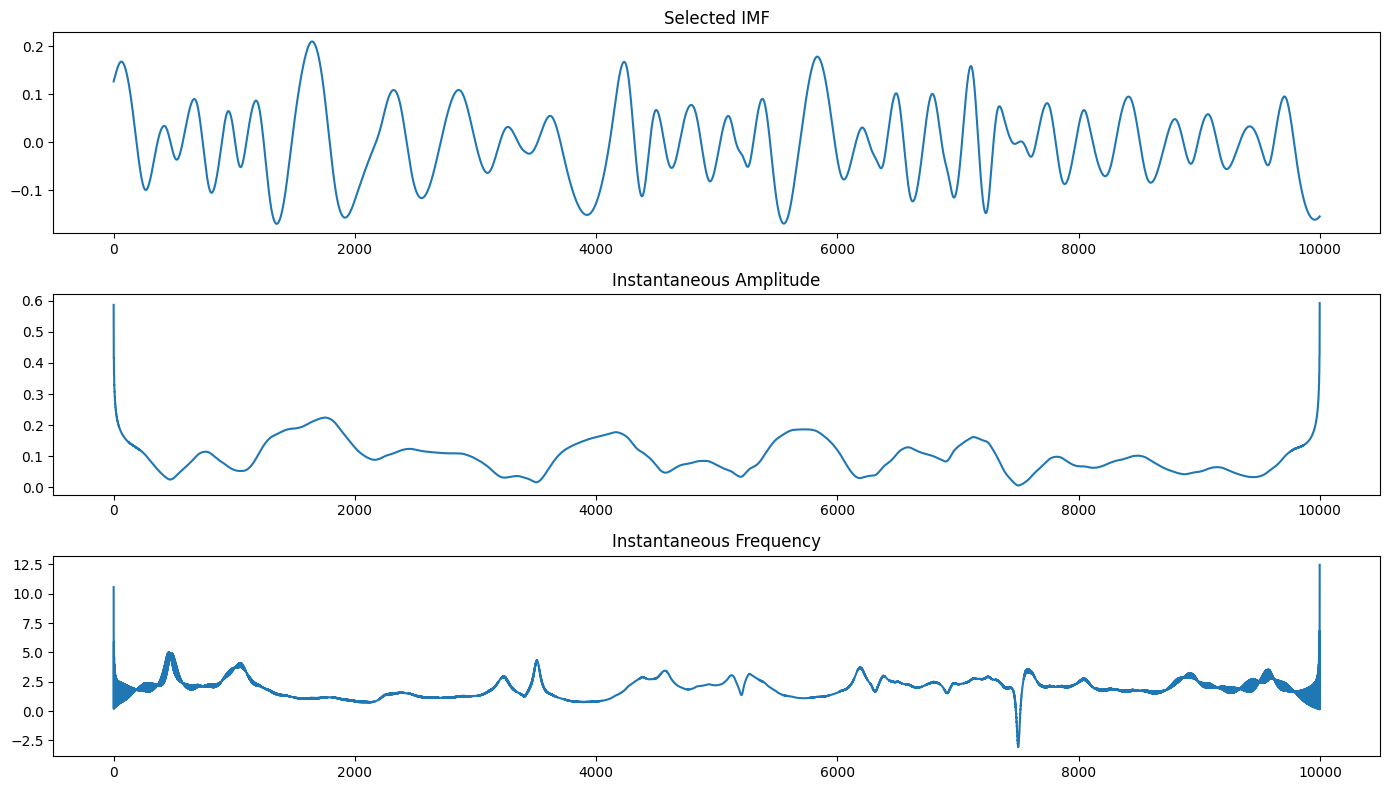


HHT Features

Mean_Amplitude : 0.0991925606146033
Std_Amplitude : 0.05164333783948156
Max_Amplitude : 0.5927799353688473
Mean_Frequency : 1.9548324204934202
Std_Frequency : 0.7946113305385737
Max_Frequency : 12.463125385995754


In [58]:
#Advanced Signal Processing
#HHT
from scipy.signal import hilbert
#SELECT IMPORTANT IMF
important_imf = imfs[
    np.argmax(imf_energy)
]

print(
    "Selected IMF:",
    np.argmax(imf_energy)+1
)
#APPLY HILBERT TRANSFORM
analytic_signal = hilbert(
    important_imf
)
#INSTANTANEOUS AMPLITUDE->Measures signal energy variation over time
instantaneous_amplitude = np.abs(
    analytic_signal
)
#INSTANTANEOUS Phase->Phase variation is needed to compute instantaneous frequency
instantaneous_phase = np.unwrap(
    np.angle(analytic_signal)
)
#INSTANTANEOUS FREQUENCY->This becomes HHT-based ECG dynamics.
fs = 700

instantaneous_frequency = (
    np.diff(instantaneous_phase)
    / (2.0 * np.pi)
    * fs
)
#VISUALIZATION
plt.figure(figsize=(14,8))

plt.subplot(3,1,1)
plt.plot(important_imf)
plt.title("Selected IMF")

plt.subplot(3,1,2)
plt.plot(instantaneous_amplitude)
plt.title("Instantaneous Amplitude")

plt.subplot(3,1,3)
plt.plot(instantaneous_frequency)
plt.title("Instantaneous Frequency")

plt.tight_layout()

plt.show()

# HHT FEATURES

hht_features = {

    "Mean_Amplitude":
        np.mean(
            instantaneous_amplitude
        ),

    "Std_Amplitude":
        np.std(
            instantaneous_amplitude
        ),

    "Max_Amplitude":
        np.max(
            instantaneous_amplitude
        ),

    "Mean_Frequency":
        np.mean(
            instantaneous_frequency
        ),

    "Std_Frequency":
        np.std(
            instantaneous_frequency
        ),

    "Max_Frequency":
        np.max(
            instantaneous_frequency
        )
}

print("\nHHT Features\n")

for key, value in hht_features.items():

    print(
        key,
        ":",
        value
    )

In [59]:
import pandas as pd

hht_features_df = pd.DataFrame(
    [hht_features]
)

print(hht_features_df)

hht_features_df.to_csv(
    "hht_features.csv",
    index=False
)

   Mean_Amplitude  Std_Amplitude  Max_Amplitude  Mean_Frequency  \
0        0.099193       0.051643        0.59278        1.954832   

   Std_Frequency  Max_Frequency  
0       0.794611      12.463125  


In [60]:

# ADVANCED HHT FEATURES

advanced_hht_features = {

    "Mean_IF":
        np.mean(
            instantaneous_frequency
        ),

    "Std_IF":
        np.std(
            instantaneous_frequency
        ),

    "Peak_IF":
        np.max(
            instantaneous_frequency
        ),

    "IF_Energy":
        np.sum(
            instantaneous_frequency**2
        )
}

print("\nAdvanced HHT Features\n")

for key, value in advanced_hht_features.items():

    print(
        key,
        ":",
        value
    )


Advanced HHT Features

Mean_IF : 1.9548324204934202
Std_IF : 0.7946113305385737
Peak_IF : 12.463125385995754
IF_Energy : 44523.31681136562


In [61]:
import pandas as pd

advanced_hht_df = pd.DataFrame(
    [advanced_hht_features]
)

print(advanced_hht_df)

advanced_hht_df.to_csv(
    "advanced_hht_features.csv",
    index=False
)

    Mean_IF    Std_IF    Peak_IF     IF_Energy
0  1.954832  0.794611  12.463125  44523.316811


In [63]:
!pip install antropy
import antropy as ant



In [67]:

# ADVANCED HHT FEATURES


mean_if = np.mean(
    instantaneous_frequency
)

std_if = np.std(
    instantaneous_frequency
)

peak_if = np.max(
    instantaneous_frequency
)

if_energy = np.sum(
    instantaneous_frequency**2
)

if_entropy = ant.sample_entropy(
    instantaneous_frequency
)

if_variability_index = (
    std_if / mean_if
)

print("Mean IF:", mean_if)
print("Std IF:", std_if)
print("Peak IF:", peak_if)
print("IF Energy:", if_energy)
print("IF Entropy:", if_entropy)
print(
    "IF Variability Index:",
    if_variability_index
)

Mean IF: 1.9548324204934202
Std IF: 0.7946113305385737
Peak IF: 12.463125385995754
IF Energy: 44523.31681136562
IF Entropy: 0.033679934166925364
IF Variability Index: 0.40648565176651075


In [74]:
sample_entropy = ant.sample_entropy(hybrid_ecg)

approx_entropy = ant.app_entropy(hybrid_ecg)

perm_entropy = ant.perm_entropy(
    hybrid_ecg,
    normalize=True
)
print(sample_entropy)
print(approx_entropy)
print(perm_entropy)

0.08443396603088678
0.131782254676867
0.48882743472066004


In [71]:

# CREATE ADVANCED ECG FEATURE DATAFRAME

advanced_ecg_df = ecg_features_df.copy()

# ENTROPY FEATURES

advanced_ecg_df["Sample_Entropy"] = sample_entropy

advanced_ecg_df["Approximate_Entropy"] = approx_entropy

advanced_ecg_df["Permutation_Entropy"] = perm_entropy

# HHT FEATURES

advanced_ecg_df["Mean_IF"] = mean_if

advanced_ecg_df["Std_IF"] = std_if

advanced_ecg_df["Peak_IF"] = peak_if

advanced_ecg_df["IF_Energy"] = if_energy

advanced_ecg_df["IF_Entropy"] = if_entropy+++

advanced_ecg_df["IF_Variability_Index"] = (
    if_variability_index
)

print("Advanced ECG Shape:")

print(advanced_ecg_df.shape)

print("\nTotal NaNs:")

print(
    advanced_ecg_df.isna().sum().sum()
)

advanced_ecg_df.head()

Advanced ECG Shape:
(404, 44)

Total NaNs:
4444


,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_RMSSD,HRV_SDSD,...,HRV_LnHF,Sample_Entropy,Approximate_Entropy,Permutation_Entropy,Mean_IF,Std_IF,Peak_IF,IF_Energy,IF_Entropy,IF_Variability_Index
0,837.268908,78.296147,NaN,NaN,NaN,NaN,NaN,NaN,54.333540,54.947901,...,-4.400893,0.084434,0.131782,0.488827,1.954832,0.794611,12.463125,44523.316811,0.03368,0.406486
1,792.277992,84.704006,NaN,NaN,NaN,NaN,NaN,NaN,35.459408,35.901460,...,-4.849414,0.084434,0.131782,0.488827,1.954832,0.794611,12.463125,44523.316811,0.03368,0.406486
2,743.333333,64.075122,NaN,NaN,NaN,NaN,NaN,NaN,28.902220,29.175389,...,-5.225613,0.084434,0.131782,0.488827,1.954832,0.794611,12.463125,44523.316811,0.03368,0.406486
3,758.721805,52.421548,NaN,NaN,NaN,NaN,NaN,NaN,39.789851,40.191367,...,-4.474819,0.084434,0.131782,0.488827,1.954832,0.794611,12.463125,44523.316811,0.03368,0.406486
4,767.490347,43.078009,NaN,NaN,NaN,NaN,NaN,NaN,36.946980,37.346034,...,-2.990438,0.084434,0.131782,0.488827,1.954832,0.794611,12.463125,44523.316811,0.03368,0.406486


In [72]:
# REMOVE FULLY NaN FEATURES

advanced_ecg_clean = advanced_ecg_df.dropna(
    axis=1,
    how='all'
)

print(
    "Before:",
    advanced_ecg_df.shape
)

print(
    "After:",
    advanced_ecg_clean.shape
)

print(
    "Remaining NaNs:",
    advanced_ecg_clean.isna().sum().sum()
)

Before: (404, 44)
After: (404, 33)
Remaining NaNs: 0


In [73]:
advanced_ecg_clean.to_csv(
    "advanced_ecg_features.csv",
    index=False
)

In [75]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = advanced_ecg_clean
y = window_labels

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(
    "Advanced ECG Accuracy:",
    accuracy_score(y_test, y_pred)
)

Advanced ECG Accuracy: 0.9382716049382716


In [76]:
print(advanced_ecg_clean.shape)
print(window_labels.shape)

(404, 33)
(404,)


In [77]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(classification_report(
    y_test,
    y_pred
))

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.97      0.97        72
           1       0.75      0.67      0.71         9

    accuracy                           0.94        81
   macro avg       0.85      0.82      0.84        81
weighted avg       0.94      0.94      0.94        81

[[70  2]
 [ 3  6]]


In [79]:
print(type(X_train))
print(type(y_train))

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>


In [80]:
from xgboost import XGBClassifier

advanced_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

advanced_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

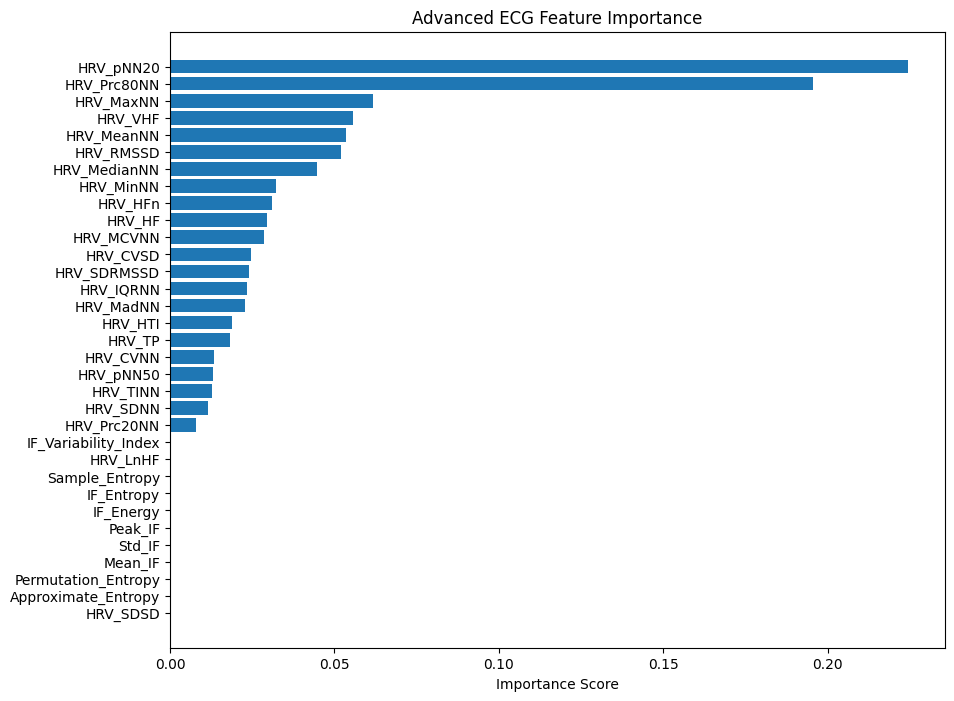

In [81]:
importance = advanced_model.feature_importances_

feature_names = advanced_ecg_clean.columns

sorted_idx = importance.argsort()

plt.figure(figsize=(10,8))

plt.barh(
    feature_names[sorted_idx],
    importance[sorted_idx]
)

plt.xlabel("Importance Score")

plt.title(
    "Advanced ECG Feature Importance"
)

plt.show()

In [82]:
advanced_ecg_clean.to_csv(
    "advanced_ecg_features.csv",
    index=False
)

In [84]:
# ADVANCED EDA PROCESSING
# TONIC-PHASIC DECOMPOSITION
# ADAPTIVE PEAK ENHANCEMENT
!pip install cvxopt

import cvxopt
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [85]:
# CHECK INPUT
print("EDA Shape:", eda.shape)

EDA Shape: (24316,)


Filtered EDA Shape: (24316,)


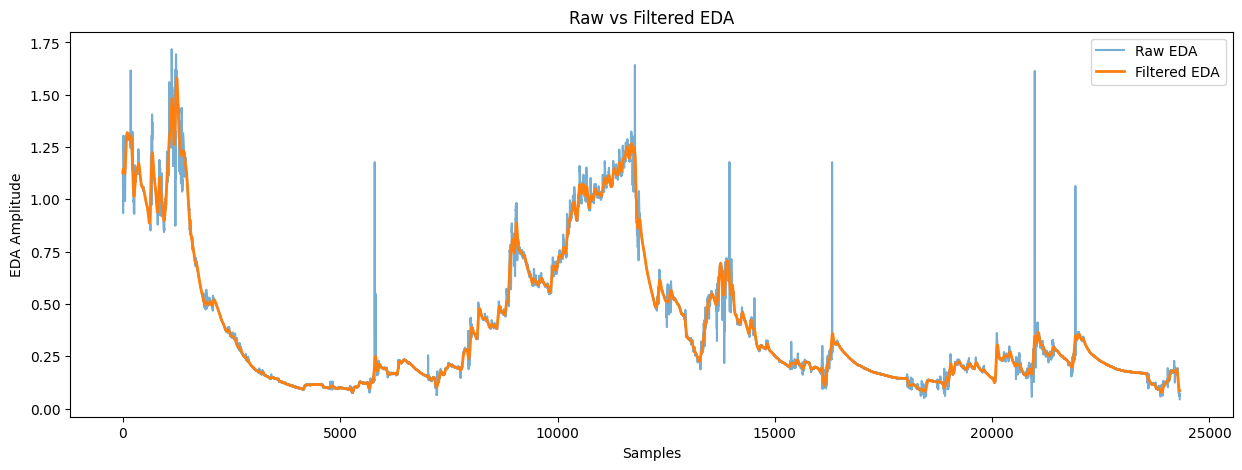

In [86]:

# LOW PASS FILTERING


fs_eda = 4

b, a = butter(
    4,
    0.05,
    btype='low',
    fs=fs_eda
)

filtered_eda = filtfilt(
    b,
    a,
    eda
)

print("Filtered EDA Shape:",
      filtered_eda.shape)

# RAW VS FILTERED


plt.figure(figsize=(15,5))

plt.plot(
    eda,
    label="Raw EDA",
    alpha=0.6
)

plt.plot(
    filtered_eda,
    label="Filtered EDA",
    linewidth=2
)

plt.title(
    "Raw vs Filtered EDA"
)

plt.xlabel("Samples")

plt.ylabel("EDA Amplitude")

plt.legend()

plt.show()


Tonic Shape: (24316,)
Phasic Shape: (24316,)


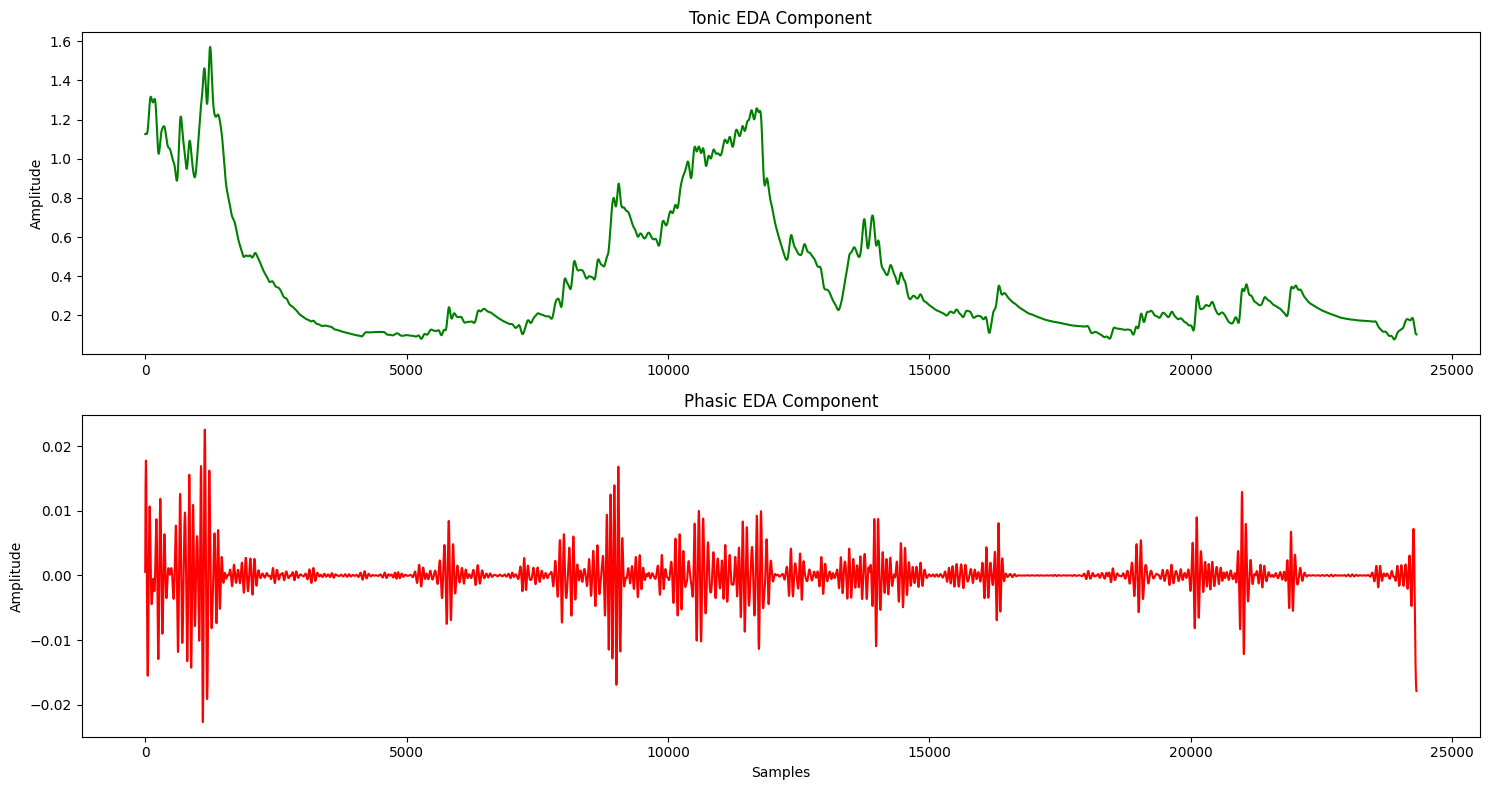

In [87]:
# TONIC COMPONENT

tonic_eda = filtfilt(
    b,
    a,
    filtered_eda
)

# PHASIC COMPONENT

phasic_eda = (
    filtered_eda
    -
    tonic_eda
)

print(
    "Tonic Shape:",
    tonic_eda.shape
)

print(
    "Phasic Shape:",
    phasic_eda.shape
)


# TONIC + PHASIC VISUALIZATION


plt.figure(figsize=(15,8))

plt.subplot(2,1,1)

plt.plot(
    tonic_eda,
    color='green'
)

plt.title(
    "Tonic EDA Component"
)

plt.ylabel("Amplitude")

plt.subplot(2,1,2)

plt.plot(
    phasic_eda,
    color='red'
)

plt.title(
    "Phasic EDA Component"
)

plt.xlabel("Samples")

plt.ylabel("Amplitude")

plt.tight_layout()

plt.show()

In [88]:

# ADAPTIVE PEAK ENHANCEMENT

threshold = (
    np.mean(
        np.abs(phasic_eda)
    )
    +
    1.5 *
    np.std(phasic_eda)
)

print(
    "Adaptive Threshold:",
    threshold
)

enhanced_phasic = np.where(

    np.abs(phasic_eda) > threshold,

    phasic_eda,

    0
)

print(
    "Enhanced Phasic Shape:",
    enhanced_phasic.shape
)

Adaptive Threshold: 0.006080679106665866
Enhanced Phasic Shape: (24316,)


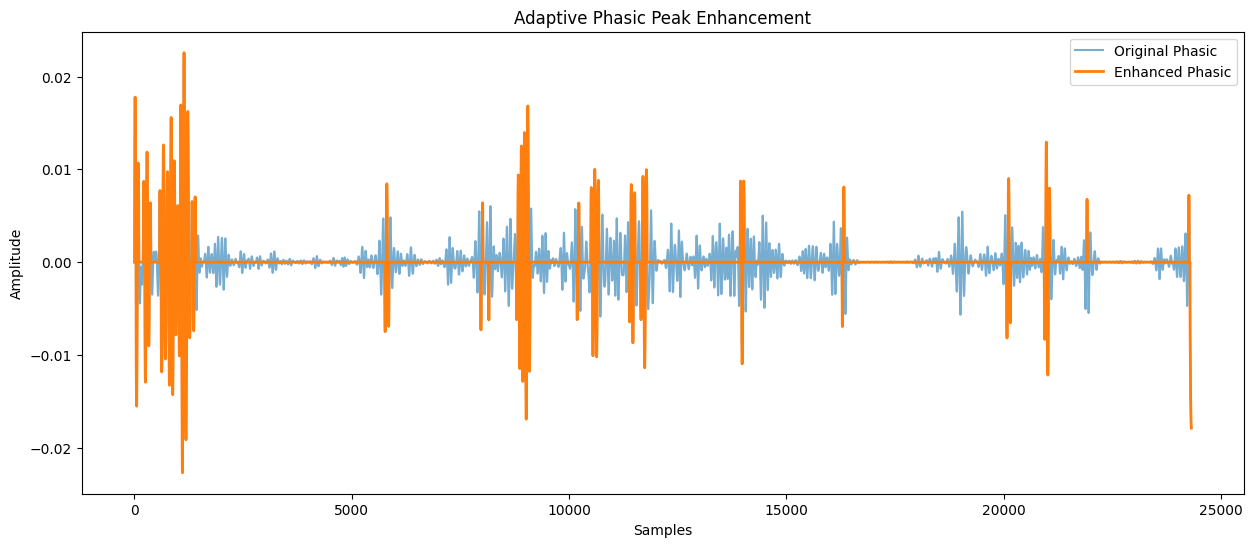

In [89]:
# VISUALIZATION

plt.figure(figsize=(15,6))

plt.plot(
    phasic_eda,
    label="Original Phasic",
    alpha=0.6
)

plt.plot(
    enhanced_phasic,
    label="Enhanced Phasic",
    linewidth=2
)

plt.title(
    "Adaptive Phasic Peak Enhancement"
)

plt.xlabel("Samples")

plt.ylabel("Amplitude")

plt.legend()

plt.show()

In [90]:

# SAVE SIGNALS

np.save(
    "tonic_eda.npy",
    tonic_eda
)

np.save(
    "phasic_eda.npy",
    phasic_eda
)

np.save(
    "enhanced_phasic.npy",
    enhanced_phasic
)

print("\nAdvanced EDA Processing Completed")


Advanced EDA Processing Completed


In [91]:
print(tonic_eda.shape)
print(phasic_eda.shape)
print(enhanced_phasic.shape)

(24316,)
(24316,)
(24316,)


In [92]:
import numpy as np
import pandas as pd
import pywt
import antropy as ant
from scipy.signal import butter, filtfilt


# ADVANCED EDA WINDOW FEATURE EXTRACTION

advanced_eda_window_feature_list = []

# Low-pass filter
b_lp, a_lp = butter(
    4,
    0.05,
    btype='low',
    fs=4
)

for eda_window_segment in eda_windows:

    try:
# FILTERING

        filtered_eda_window = filtfilt(
            b_lp,
            a_lp,
            eda_window_segment
        )

        tonic_eda_window = filtfilt(
            b_lp,
            a_lp,
            filtered_eda_window
        )

        phasic_eda_window = (
            filtered_eda_window
            -
            tonic_eda_window
        )

         # ADAPTIVE PEAK ENHANCEMENT

        threshold_window = (
            np.mean(
                np.abs(phasic_eda_window)
            )
            +
            1.5 *
            np.std(phasic_eda_window)
        )

        enhanced_phasic_window = np.where(
            np.abs(phasic_eda_window)
            > threshold_window,
            phasic_eda_window,
            0
        )

       # WAVELET

        coeffs = pywt.wavedec(
            enhanced_phasic_window,
            'db4',
            level=4
        )

        wavelet_energy = []

        for coeff in coeffs:

            wavelet_energy.append(
                np.sum(
                    coeff**2
                )
            )

        # MULTISCALE ENTROPY

        mse_values = []

        for scale in range(1,6):

            coarse_signal = []

            for i in range(
                0,
                len(enhanced_phasic_window)-scale,
                scale
            ):

                coarse_signal.append(
                    np.mean(
                        enhanced_phasic_window[
                            i:i+scale
                        ]
                    )
                )

            coarse_signal = np.array(
                coarse_signal
            )

            if (
                len(coarse_signal) > 10
                and
                np.std(coarse_signal) > 0
            ):

                mse = ant.sample_entropy(
                    coarse_signal
                )

            else:

                mse = 0

            mse_values.append(mse)

        # DYNAMIC VARIABILITY

        eda_diff = np.diff(
            enhanced_phasic_window
        )

        dynamic_variability = np.std(
            eda_diff
        )

        fluctuation_energy = np.sum(
            eda_diff**2
        )

        if (
            len(eda_diff) > 10
            and
            np.std(eda_diff) > 0
        ):

            peak_irregularity = ant.sample_entropy(
                eda_diff
            )

        else:

            peak_irregularity = 0

        # SYNCHRONIZATION

        d2 = coeffs[2]
        d3 = coeffs[3]
        d4 = coeffs[4]

        min_len = min(
            len(d2),
            len(d3),
            len(d4)
        )

        d2 = d2[:min_len]
        d3 = d3[:min_len]
        d4 = d4[:min_len]

        if (
            min_len > 2
            and
            np.std(d2) > 0
            and
            np.std(d3) > 0
        ):

            corr_d2_d3 = np.corrcoef(
                d2,
                d3
            )[0,1]

        else:

            corr_d2_d3 = 0

        if (
            min_len > 2
            and
            np.std(d3) > 0
            and
            np.std(d4) > 0
        ):

            corr_d3_d4 = np.corrcoef(
                d3,
                d4
            )[0,1]

        else:

            corr_d3_d4 = 0

        # OSCILLATION STABILITY

        stability_scores = []

        for i in range(
            0,
            len(enhanced_phasic_window)-20,
            20
        ):

            segment = enhanced_phasic_window[
                i:i+20
            ]

            stability_scores.append(
                np.std(segment)
            )

        oscillation_stability = np.mean(
            stability_scores
        )

        oscillation_instability = np.std(
            stability_scores
        )

        # TRANSITION DYNAMICS


        transition_signal = np.diff(
            enhanced_phasic_window
        )

        transition_rate = np.mean(
            np.abs(
                transition_signal
            )
        )

        transition_strength = np.max(
            np.abs(
                transition_signal
            )
        )

        transition_irregularity = np.std(
            transition_signal
        )

        # STORE FEATURES

        features = {

            "Tonic_Mean":
                np.mean(tonic_eda_window),

            "Tonic_STD":
                np.std(tonic_eda_window),

            "Phasic_Energy":
                np.sum(
                    phasic_eda_window**2
                ),

            "Phasic_STD":
                np.std(
                    phasic_eda_window
                ),

            "Phasic_Peak":
                np.max(
                    phasic_eda_window
                ),

            "Wavelet_Energy_1":
                wavelet_energy[0],

            "Wavelet_Energy_2":
                wavelet_energy[1],

            "Wavelet_Energy_3":
                wavelet_energy[2],

            "Wavelet_Energy_4":
                wavelet_energy[3],

            "Wavelet_Energy_5":
                wavelet_energy[4],

            "D2_D3_Sync":
                corr_d2_d3,

            "D3_D4_Sync":
                corr_d3_d4,

            "Oscillation_Stability":
                oscillation_stability,

            "Oscillation_Instability":
                oscillation_instability,

            "Transition_Rate":
                transition_rate,

            "Transition_Strength":
                transition_strength,

            "Transition_Irregularity":
                transition_irregularity,

            "MSE_1":
                mse_values[0],

            "MSE_2":
                mse_values[1],

            "MSE_3":
                mse_values[2],

            "MSE_4":
                mse_values[3],

            "MSE_5":
                mse_values[4],

            "Dynamic_Variability":
                dynamic_variability,

            "Fluctuation_Energy":
                fluctuation_energy,

            "Peak_Irregularity":
                peak_irregularity
        }

        advanced_eda_window_feature_list.append(
            features
        )

    except:

        pass


# DATAFRAME

advanced_eda_window_df = pd.DataFrame(
    advanced_eda_window_feature_list
)

print(
    "Advanced EDA Shape:",
    advanced_eda_window_df.shape
)

print(
    "Total NaNs:",
    advanced_eda_window_df.isna().sum().sum()
)

display(
    advanced_eda_window_df.head()
)

Advanced EDA Shape: (404, 25)
Total NaNs: 0


,Tonic_Mean,Tonic_STD,Phasic_Energy,Phasic_STD,Phasic_Peak,Wavelet_Energy_1,Wavelet_Energy_2,Wavelet_Energy_3,Wavelet_Energy_4,Wavelet_Energy_5,...,Transition_Strength,Transition_Irregularity,MSE_1,MSE_2,MSE_3,MSE_4,MSE_5,Dynamic_Variability,Fluctuation_Energy,Peak_Irregularity
0,1.206508,0.077027,0.013234,0.009922,0.017491,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1.289965,0.020880,0.002309,0.004085,0.007644,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1.271621,0.030658,0.006919,0.007023,0.006175,0.011508,0.000719,0.0002,0.000058,0.000019,...,0.016232,0.001482,0.018634,0.038438,0.058841,0.080043,0.105361,0.001482,0.000264,0.017966
3,1.148874,0.151127,0.016620,0.011753,0.018486,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,1.101648,0.049711,0.004313,0.005730,0.008117,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [94]:

# FINAL ADVANCED MULTIMODAL FUSION
# ECG + EDA

import pandas as pd
import numpy as np

# CHECK INPUT SHAPES

print("Advanced ECG Shape:")
print(advanced_ecg_clean.shape)

print("\nAdvanced EDA Shape:")
print(advanced_eda_window_df.shape)

# FUSION


advanced_fused_df = pd.concat(

    [
        advanced_ecg_clean.reset_index(drop=True),

        advanced_eda_window_df.reset_index(drop=True)
    ],

    axis=1
)

# CHECK RESULTS


print("\nFusion Shape:")
print(
    advanced_fused_df.shape
)

print("\nTotal NaNs:")
print(
    advanced_fused_df.isna().sum().sum()
)

print("\nLabel Shape:")
print(
    window_labels.shape
)


# DISPLAY


display(
    advanced_fused_df.head()
)

# SAVE

advanced_fused_df.to_csv(
    "advanced_multimodal_features.csv",
    index=False
)

print(
    "\nAdvanced Fusion Saved Successfully"
)

Advanced ECG Shape:
(404, 33)

Advanced EDA Shape:
(404, 25)

Fusion Shape:
(404, 58)

Total NaNs:
0

Label Shape:
(404,)


,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,...,Transition_Strength,Transition_Irregularity,MSE_1,MSE_2,MSE_3,MSE_4,MSE_5,Dynamic_Variability,Fluctuation_Energy,Peak_Irregularity
0,837.268908,78.296147,54.333540,54.947901,0.093514,0.064894,838.571429,96.369,0.114920,130.357143,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,792.277992,84.704006,35.459408,35.901460,0.106912,0.044756,792.857143,108.018,0.136239,134.285714,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,743.333333,64.075122,28.902220,29.175389,0.086200,0.038882,742.857143,69.894,0.094088,92.142857,...,0.016232,0.001482,0.018634,0.038438,0.058841,0.080043,0.105361,0.001482,0.000264,0.017966
3,758.721805,52.421548,39.789851,40.191367,0.069092,0.052443,757.142857,57.186,0.075529,73.571429,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,767.490347,43.078009,36.946980,37.346034,0.056128,0.048140,765.714286,31.770,0.041491,48.571429,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



Advanced Fusion Saved Successfully


In [95]:

# SMOTE + XGBOOST ON FUSED FEATURES


!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier
import numpy as np

# FEATURES

X = advanced_fused_df

# LABELS

y = window_labels

print("Original Distribution")

print(
    np.unique(
        y,
        return_counts=True
    )
)


# SMOTE

smote = SMOTE(
    random_state=42
)

X_balanced, y_balanced = smote.fit_resample(
    X,
    y
)

print("\nAfter SMOTE")

print(
    np.unique(
        y_balanced,
        return_counts=True
    )
)

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X_balanced,

    y_balanced,

    test_size=0.2,

    random_state=42,

    stratify=y_balanced
)


# XGBOOST

model = XGBClassifier(

    n_estimators=200,

    max_depth=6,

    learning_rate=0.05,

    random_state=42
)

model.fit(
    X_train,
    y_train
)

# PREDICTIONS


y_pred = model.predict(
    X_test
)


# RESULTS

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "\nAccuracy:",
    accuracy
)

print(
    "\nClassification Report\n"
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    "\nConfusion Matrix\n"
)

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

Original Distribution
(array([0, 1]), array([361,  43]))

After SMOTE
(array([0, 1]), array([361, 361]))

Accuracy: 0.9793103448275862

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        73
           1       0.97      0.99      0.98        72

    accuracy                           0.98       145
   macro avg       0.98      0.98      0.98       145
weighted avg       0.98      0.98      0.98       145


Confusion Matrix

[[71  2]
 [ 1 71]]


In [96]:

# 5-FOLD CROSS VALIDATION

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(

    model,

    X_balanced,

    y_balanced,

    cv=cv,

    scoring='accuracy'
)

print("5-Fold Scores")

print(scores)

print("\nMean Accuracy")

print(scores.mean())

print("\nStd")

print(scores.std())

5-Fold Scores
[0.95862069 0.97931034 0.96527778 0.99305556 0.99305556]

Mean Accuracy
0.9778639846743294

Std
0.01408812703384436


In [97]:

# 10-FOLD CROSS VALIDATION

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scores10 = cross_val_score(

    model,

    X_balanced,

    y_balanced,

    cv=cv10,

    scoring='accuracy'
)

print("10-Fold Scores")

print(scores10)

print("\nMean Accuracy")

print(scores10.mean())

print("\nStd")

print(scores10.std())

10-Fold Scores
[0.95890411 0.95890411 0.95833333 0.98611111 0.98611111 0.97222222
 1.         0.98611111 1.         0.98611111]

Mean Accuracy
0.9792808219178081

Std
0.015376026798161


In [98]:
advanced_fused_df.to_csv(
    "final_multimodal_dataset.csv",
    index=False
)

In [99]:
import pandas as pd

pd.DataFrame(
    window_labels,
    columns=["Stress_Label"]
).to_csv(
    "final_labels.csv",
    index=False
)

In [102]:
final_dataset = advanced_fused_df.copy()

final_dataset["Stress_Label"] = window_labels

final_dataset.to_csv(
    "final_multimodal_dataset_with_labels.csv",
    index=False
)


In [103]:
# TRANSFORMER INPUT PREPARATION

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

# FEATURES
X = advanced_fused_df

# LABELS
y = window_labels

# SMOTE

smote = SMOTE(random_state=42)

X_balanced, y_balanced = smote.fit_resample(
    X,
    y
)

print(
    "After SMOTE:",
    X_balanced.shape
)

# STANDARDIZATION

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_balanced
)

# RESHAPE FOR TRANSFORMER

X_transformer = X_scaled.reshape(

    X_scaled.shape[0],

    X_scaled.shape[1],

    1
)

print(
    "Transformer Shape:",
    X_transformer.shape
)

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X_transformer,

    y_balanced,

    test_size=0.2,

    random_state=42,

    stratify=y_balanced
)

print(
    "Train Shape:",
    X_train.shape
)

print(
    "Test Shape:",
    X_test.shape
)

After SMOTE: (722, 58)
Transformer Shape: (722, 58, 1)
Train Shape: (577, 58, 1)
Test Shape: (145, 58, 1)


In [104]:

# TRANSFORMER MODEL

import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    MultiHeadAttention,
    LayerNormalization,
    Dense,
    Dropout,
    GlobalAveragePooling1D
)
from tensorflow.keras.models import Model

# INPUT

inputs = Input(
    shape=(58,1)
)

# MULTI-HEAD ATTENTION

attention = MultiHeadAttention(
    num_heads=4,
    key_dim=16
)(
    inputs,
    inputs
)

x = LayerNormalization()(
    attention + inputs
)


# FEED FORWARD NETWORK

ffn = Dense(
    64,
    activation='relu'
)(x)

ffn = Dense(
    32,
    activation='relu'
)(ffn)

x = LayerNormalization()(
    ffn
)

# GLOBAL POOLING

x = GlobalAveragePooling1D()(x)

x = Dropout(0.3)(x)

# CLASSIFICATION

outputs = Dense(
    1,
    activation='sigmoid'
)(x)

# MODEL

transformer_model = Model(
    inputs,
    outputs
)

transformer_model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)

transformer_model.summary()

# TRAINING

history = transformer_model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=30,

    batch_size=32,

    verbose=1
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 58, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 58, 1)     │        449 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 58, 1)     │          0 │ multi_head_atten… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 58, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 58, 64)    │        128 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 58, 32)    │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 58, 32)    │         64 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,756 (10.77 KB)

 Trainable params: 2,756 (10.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 334ms/step - accuracy: 0.4881 - loss: 0.6935 - val_accuracy: 0.5431 - val_loss: 0.6929
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.4859 - loss: 0.6932 - val_accuracy: 0.4569 - val_loss: 0.6932
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.4946 - loss: 0.6931 - val_accuracy: 0.4569 - val_loss: 0.6936
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.5141 - loss: 0.6933 - val_accuracy: 0.4569 - val_loss: 0.6945
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.5119 - loss: 0.6929 - val_accuracy: 0.4569 - val_loss: 0.6948
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.5119 - loss: 0.6928 - val_accuracy: 0.4569 - val_loss: 0.6950
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.5119 - loss: 0.6929 - val_accuracy: 0.4569 - val_loss: 0.6953
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.5119 - loss: 0.6934 - val_accuracy: 0

In [105]:

# EVALUATION

loss, accuracy = transformer_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    "Transformer Accuracy:",
    accuracy
)

Transformer Accuracy: 0.4965517222881317


In [106]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = (transformer_model.predict(X_test) > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step
[[ 0 73]
 [ 0 72]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        73
           1       0.50      1.00      0.66        72

    accuracy                           0.50       145
   macro avg       0.25      0.50      0.33       145
weighted avg       0.25      0.50      0.33       145



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [107]:
import pandas as pd

history_df = pd.DataFrame(history.history)

print(history_df.tail())

    accuracy      loss  val_accuracy  val_loss
25  0.509761  0.693081      0.456897  0.694274
26  0.507592  0.693111      0.456897  0.694114
27  0.509761  0.692748      0.456897  0.694141
28  0.505423  0.692998      0.456897  0.694324
29  0.520607  0.692539      0.456897  0.694050


In [108]:
print(X_train.shape)
print(y_train.shape)

print(np.unique(y_train, return_counts=True))

(577, 58, 1)
(577,)
(array([0, 1]), array([288, 289]))


In [109]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# =====================================
# INPUT
# =====================================

inputs = Input(shape=(58,1))

# =====================================
# FEATURE EMBEDDING
# =====================================

x = Dense(32, activation="relu")(inputs)

# =====================================
# TRANSFORMER BLOCK
# =====================================

attn_output = MultiHeadAttention(
    num_heads=4,
    key_dim=8
)(x, x)

x = LayerNormalization()(
    x + attn_output
)

ffn = Dense(
    64,
    activation="relu"
)(x)

ffn = Dense(
    32
)(ffn)

x = LayerNormalization()(
    x + ffn
)

# =====================================
# CLASSIFIER
# =====================================

x = GlobalAveragePooling1D()(x)

x = Dense(
    64,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    1,
    activation="sigmoid"
)(x)

model2 = Model(
    inputs,
    outputs
)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model2.summary()

# =====================================
# TRAIN
# =====================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history2 = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 58, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 58, 32)    │         64 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 58, 32)    │      4,224 │ dense_3[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 58, 32)    │          0 │ dense_3[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 58, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 58, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 58, 32)    │      2,080 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 58, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 58, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      2,112 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,785 (42.13 KB)

 Trainable params: 10,785 (42.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.6095 - loss: 0.6598 - val_accuracy: 0.6638 - val_loss: 0.6373
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6790 - loss: 0.6343 - val_accuracy: 0.6724 - val_loss: 0.6208
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6963 - loss: 0.6087 - val_accuracy: 0.6983 - val_loss: 0.6092
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7137 - loss: 0.5909 - val_accuracy: 0.6897 - val_loss: 0.6069
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7007 - loss: 0.5943 - val_accuracy: 0.6983 - val_loss: 0.5963
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7202 - loss: 0.5722 - val_accuracy: 0.6810 - val_loss: 0.5912
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7072 - loss: 0.5709 - val_accuracy: 0.6983 - val_loss: 0.6112
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7093 - loss: 0.5890 - val_accuracy: 0.6379 - 

In [110]:
loss, acc = model2.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Improved Transformer Accuracy:", acc)

Improved Transformer Accuracy: 0.7379310131072998


In [112]:
import pandas as pd

history_df = pd.DataFrame(history2.history)

history_df.tail(10)

,accuracy,loss,val_accuracy,val_loss
40,0.748373,0.512700,0.724138,0.562983
41,0.752711,0.528403,0.732759,0.551998
42,0.754881,0.517629,0.732759,0.548252
43,0.763557,0.527658,0.706897,0.564348
44,0.750542,0.525566,0.706897,0.564744
45,0.757050,0.518450,0.732759,0.541133
46,0.765727,0.518854,0.732759,0.546660
47,0.763557,0.510202,0.672414,0.591475
48,0.744035,0.526656,0.724138,0.541869
49,0.774403,0.512023,0.715517,0.560320


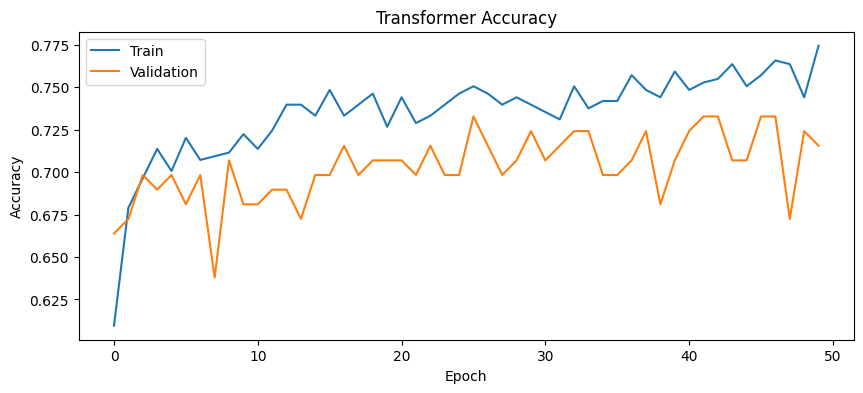

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Transformer Accuracy")

plt.show()

In [114]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history3 = model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/80
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.7527 - loss: 0.5180 - val_accuracy: 0.7241 - val_loss: 0.5499
Epoch 2/80
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7722 - loss: 0.5104 - val_accuracy: 0.7328 - val_loss: 0.5368
Epoch 3/80
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7636 - loss: 0.5050 - val_accuracy: 0.7241 - val_loss: 0.5448
Epoch 4/80
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7570 - loss: 0.5062 - val_accuracy: 0.7328 - val_loss: 0.5363
Epoch 5/80
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7527 - loss: 0.5143 - val_accuracy: 0.7414 - val_loss: 0.5492
Epoch 6/80
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7657 - loss: 0.5042 - val_accuracy: 0.7069 - val_loss: 0.5427
Epoch 7/80
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7766 - loss: 0.5260 - val_accuracy: 0.7414 - val_loss: 0.5248
Epoch 8/80
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7679 - loss: 0.4929 - val_accuracy: 0.7155 - v

In [115]:
loss, acc = model2.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Transformer Accuracy:", acc)

Transformer Accuracy: 0.7448275685310364


In [116]:
# =====================================================
# FINAL HYBRID TRANSFORMER
# Dense Embedding + 2 Transformer Blocks + MLP
# =====================================================

import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# =====================================================
# INPUT
# =====================================================

inputs = Input(shape=(58,1))

# =====================================================
# FEATURE EMBEDDING
# =====================================================

x = Dense(
    64,
    activation='relu'
)(inputs)

# =====================================================
# TRANSFORMER BLOCK 1
# =====================================================

attn1 = MultiHeadAttention(
    num_heads=8,
    key_dim=16,
    dropout=0.2
)(x, x)

x1 = LayerNormalization()(
    x + attn1
)

ffn1 = Dense(
    128,
    activation='relu'
)(x1)

ffn1 = Dropout(0.3)(ffn1)

ffn1 = Dense(
    64
)(ffn1)

x1 = LayerNormalization()(
    x1 + ffn1
)

# =====================================================
# TRANSFORMER BLOCK 2
# =====================================================

attn2 = MultiHeadAttention(
    num_heads=8,
    key_dim=16,
    dropout=0.2
)(x1, x1)

x2 = LayerNormalization()(
    x1 + attn2
)

ffn2 = Dense(
    128,
    activation='relu'
)(x2)

ffn2 = Dropout(0.3)(ffn2)

ffn2 = Dense(
    64
)(ffn2)

x2 = LayerNormalization()(
    x2 + ffn2
)

# =====================================================
# GLOBAL POOLING
# =====================================================

x = GlobalAveragePooling1D()(x2)

# =====================================================
# MLP CLASSIFIER
# =====================================================

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.4)(x)

x = Dense(
    64,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

x = Dense(
    32,
    activation='relu'
)(x)

# =====================================================
# OUTPUT
# =====================================================

outputs = Dense(
    1,
    activation='sigmoid'
)(x)

# =====================================================
# MODEL
# =====================================================

final_transformer = Model(
    inputs,
    outputs
)

final_transformer.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

final_transformer.summary()

# =====================================================
# EARLY STOPPING
# =====================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# =====================================================
# TRAINING
# =====================================================

history_final = final_transformer.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=120,

    batch_size=16,

    callbacks=[early_stop],

    verbose=1
)

# =====================================================
# EVALUATION
# =====================================================

loss, accuracy = final_transformer.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nFinal Transformer Accuracy:", accuracy)

# =====================================================
# CONFUSION MATRIX
# =====================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

y_pred = (
    final_transformer.predict(X_test)
    > 0.5
).astype(int)

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 58, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 58, 64)    │        128 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 58, 64)    │     33,216 │ dense_8[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 58, 64)    │          0 │ dense_8[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 58, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 58, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 58, 128)   │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 58, 64)    │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 58, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 58, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 58, 64)    │     33,216 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 58, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 58, 64)    │        128 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 58, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 58, 128)   │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 58, 64)    │      8,256 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 58, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 58, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                 

 Total params: 118,913 (464.50 KB)

 Trainable params: 118,913 (464.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 256ms/step - accuracy: 0.6052 - loss: 0.6645 - val_accuracy: 0.6724 - val_loss: 0.6195
Epoch 2/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.6703 - loss: 0.6102 - val_accuracy: 0.6724 - val_loss: 0.6420
Epoch 3/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.6638 - loss: 0.6210 - val_accuracy: 0.6552 - val_loss: 0.6358
Epoch 4/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.6963 - loss: 0.6022 - val_accuracy: 0.6466 - val_loss: 0.6293
Epoch 5/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.7137 - loss: 0.5879 - val_accuracy: 0.6552 - val_loss: 0.6312
Epoch 6/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.6963 - loss: 0.5942 - val_accuracy: 0.6724 - val_loss: 0.6378
Epoch 7/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.7050 - loss: 0.6016 - val_accuracy: 0.6810 - val_loss: 0.6001
Epoch 8/120
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.6855 - loss: 0.6122 - val_accur